In [65]:
import os
from pathlib import Path
import re
import warnings
from itertools import combinations

import pandas as pd
import numpy as np
from scipy.stats import wilcoxon, rankdata, binomtest

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
from IPython.display import display

In [66]:
BASE_DIR = Path.cwd().parent
RESULT_DIR = BASE_DIR / "results"
OUTPUT_DIR = RESULT_DIR / "evaluation/comparison"
TABLE_DIR = OUTPUT_DIR / "tables"
PLOT_DIR = OUTPUT_DIR / "plots"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

In [67]:
random_arguments = pd.read_csv(RESULT_DIR / "random_baseline_results/random_best_config_test_per_argument.csv")
tf_idf_arguments = pd.read_csv(RESULT_DIR / "tfidf_baseline_results/final_test_all_window2_topk8/tfidf_final_test_all_window2_topk8_argument_level.csv")
attention_arguments = pd.read_csv(RESULT_DIR / "attention_results/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_argument_level.csv")
ig_arguments = pd.read_csv(RESULT_DIR / "ig_results/ig_results_final/ig_final_all_splits_q0.4_window3_argument_level.csv")
shap_arguments = pd.read_csv(RESULT_DIR / "shap_results/shap_results_final/shap_final_test_q0.5_window0_argument_level.csv")
mil_arguments = pd.read_csv(RESULT_DIR / "mil_results/mil_span_run_singles/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=3__spans=15__stride=4__freeze=True_argument_level.csv")

argument_dfs = {
    "random": random_arguments,
    "tfidf": tf_idf_arguments,
    "attention": attention_arguments,
    "ig": ig_arguments,
    "shap": shap_arguments,
    "mil": mil_arguments,
}

common_columns = set.intersection(
    *[
        set(df.columns)
        for df in argument_dfs.values()
    ]
)

common_columns = sorted(common_columns)

print(
    f"Common columns across methods: "
    f"{len(common_columns)}\n"
)

for column in common_columns:
    print(column)

Common columns across methods: 18

confusion_type
global_row_id
is_false_negative
is_false_positive
is_true_negative
is_true_positive
issue
label
masked_text
masked_token_ratio
p_inappropriate_masked
p_inappropriate_original
post_id
prob_drop
split
text
total_masked_chars
total_masked_tokens


In [68]:
random_summary = pd.read_csv(RESULT_DIR / "random_baseline_results/random_best_config_confusion_summary.csv")
tf_idf_summary = pd.read_csv(RESULT_DIR / "tfidf_baseline_results/final_test_all_window2_topk8/tfidf_final_test_all_window2_topk8_confusion_summary.csv")
attention_summary = pd.read_csv(RESULT_DIR / "attention_results/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_confusion_summary.csv")
ig_summary = pd.read_csv(RESULT_DIR / "ig_results/ig_results_final/ig_final_all_splits_q0.4_window3_confusion_summary.csv")
shap_summary = pd.read_csv(RESULT_DIR / "shap_results/shap_results_final/shap_final_test_q0.5_window0_confusion_summary.csv")
mil_summary = pd.read_csv(RESULT_DIR / "mil_results/mil_span_run_singles/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=3__spans=15__stride=4__freeze=True_confusion_summary.csv")

summary_dfs = {
    "random": random_summary,
    "tfidf": tf_idf_summary,
    "attention": attention_summary,
    "ig": ig_summary,
    "shap": shap_summary,
    "mil": mil_summary,
}

common_columns = set.intersection(
    *[
        set(df.columns)
        for df in summary_dfs.values()
    ]
)

common_columns = sorted(common_columns)

print(
    f"Common columns across methods: "
    f"{len(common_columns)}\n"
)

for column in common_columns:
    print(column)

Common columns across methods: 8

confusion_type
mean_masked_token_ratio
mean_prob_drop
mean_total_masked_tokens
median_prob_drop
n_arguments
positive_drop_rate
std_prob_drop


# Prepare data

In [69]:
METHOD_ORDER = [
    method
    for method in [
        "random",
        "tfidf",
        "attention",
        "ig",
        "shap",
        "mil",
    ]
    if method in argument_dfs
]


METHOD_LABELS = {
    "random": "Random",
    "tfidf": "TF-IDF",
    "attention": "Attention",
    "ig": "Integrated Gradients",
    "shap": "SHAP",
    "mil": "MIL",
}


SUBSET_ORDER = [
    "Test overall",
    "Test TP",
    # "Test FP"
]


def method_label(method: str) -> str:
    """Return a readable method label."""
    return METHOD_LABELS.get(method, method)


def save_figure(
    fig: plt.Figure,
    filename: str,
) -> None:
    """Save a figure as high-resolution PNG."""
    fig.savefig(
        PLOT_DIR / f"{filename}.png",
        dpi=300,
        bbox_inches="tight",
    )

In [70]:
test_argument_frames = []

confusion_mapping = {
    "TP": "TP",
    "TRUE_POSITIVE": "TP",
    "TRUE POSITIVE": "TP",

    "FP": "FP",
    "FALSE_POSITIVE": "FP",
    "FALSE POSITIVE": "FP",

    "TN": "TN",
    "TRUE_NEGATIVE": "TN",
    "TRUE NEGATIVE": "TN",

    "FN": "FN",
    "FALSE_NEGATIVE": "FN",
    "FALSE NEGATIVE": "FN",
}


for method, df in argument_dfs.items():
    method_df = df.copy()

    method_df["method"] = method

    method_df["split"] = (
        method_df["split"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    method_df = (
        method_df
        .loc[method_df["split"].eq("test")]
        .copy()
    )

    method_df["confusion_type"] = (
        method_df["confusion_type"]
        .astype("string")
        .str.strip()
        .str.upper()
        .map(confusion_mapping)
    )

    for column in [
        "prob_drop",
        "masked_token_ratio",
        "p_inappropriate_original",
        "p_inappropriate_masked",
        "total_masked_tokens",
        "total_masked_chars",
    ]:
        method_df[column] = pd.to_numeric(
            method_df[column],
            errors="coerce",
        )

    # NaN remains NaN instead of being interpreted as False.
    method_df["positive_drop"] = np.where(
        method_df["prob_drop"].notna(),
        method_df["prob_drop"] > 0,
        np.nan,
    )

    test_argument_frames.append(method_df)


test_arguments = pd.concat(
    test_argument_frames,
    ignore_index=True,
)


print(
    f"Test rows: {len(test_arguments):,}"
)

print(
    "Test arguments per method:"
)

display(
    test_arguments
    .groupby("method")
    .agg(
        n_rows=("global_row_id", "size"),
        n_arguments=("global_row_id", "nunique"),
        n_tp=(
            "confusion_type",
            lambda values: values.eq("TP").sum(),
        ),
    )
    .reindex(METHOD_ORDER)
)

Test rows: 2,628
Test arguments per method:


,n_rows,n_arguments,n_tp
method,,,
random,438,438,186
tfidf,438,438,186
attention,438,438,186
ig,438,438,186
shap,438,438,186
mil,438,438,186


In [71]:
# ---------------------------------------------------------------------
# Prediction labels and flip metrics after perturbation
# ---------------------------------------------------------------------

CLASSIFICATION_THRESHOLD = 0.5


# Ensure probabilities are numeric.
test_arguments["p_inappropriate_original"] = pd.to_numeric(
    test_arguments["p_inappropriate_original"],
    errors="coerce",
)

test_arguments["p_inappropriate_masked"] = pd.to_numeric(
    test_arguments["p_inappropriate_masked"],
    errors="coerce",
)


# ---------------------------------------------------------------------
# Derive predictions from p(inappropriate).
#
# The binary Hugging Face classifier uses argmax over two softmax
# probabilities. For two classes, LABEL_1 is therefore selected iff
# p(inappropriate) > 0.5.
# ---------------------------------------------------------------------

test_arguments["predicted_label_original"] = np.where(
    test_arguments["p_inappropriate_original"].notna(),
    (
        test_arguments["p_inappropriate_original"]
        > CLASSIFICATION_THRESHOLD
    ).astype(int),
    np.nan,
)

test_arguments["predicted_label_masked"] = np.where(
    test_arguments["p_inappropriate_masked"].notna(),
    (
        test_arguments["p_inappropriate_masked"]
        > CLASSIFICATION_THRESHOLD
    ).astype(int),
    np.nan,
)


# ---------------------------------------------------------------------
# Generic prediction flip
# ---------------------------------------------------------------------

valid_predictions = (
    test_arguments["predicted_label_original"].notna()
    & test_arguments["predicted_label_masked"].notna()
)

test_arguments["prediction_flipped"] = np.where(
    valid_predictions,
    (
        test_arguments["predicted_label_original"]
        != test_arguments["predicted_label_masked"]
    ),
    np.nan,
)


# ---------------------------------------------------------------------
# Direction of the flip
# ---------------------------------------------------------------------

test_arguments["flip_to_appropriate"] = np.where(
    valid_predictions,
    (
        test_arguments["predicted_label_original"].eq(1)
        & test_arguments["predicted_label_masked"].eq(0)
    ),
    np.nan,
)

test_arguments["flip_to_inappropriate"] = np.where(
    valid_predictions,
    (
        test_arguments["predicted_label_original"].eq(0)
        & test_arguments["predicted_label_masked"].eq(1)
    ),
    np.nan,
)


# ---------------------------------------------------------------------
# Conditional flip rates.
#
# flip_to_appropriate_given_positive:
# Among arguments originally predicted as inappropriate,
# did masking flip the prediction to appropriate?
#
# flip_to_inappropriate_given_negative:
# Among arguments originally predicted as appropriate,
# did masking flip the prediction to inappropriate?
# ---------------------------------------------------------------------

test_arguments[
    "flip_to_appropriate_given_positive"
] = np.where(
    test_arguments["predicted_label_original"].eq(1),
    test_arguments["predicted_label_masked"].eq(0).astype(float),
    np.nan,
)

test_arguments[
    "flip_to_inappropriate_given_negative"
] = np.where(
    test_arguments["predicted_label_original"].eq(0),
    test_arguments["predicted_label_masked"].eq(1).astype(float),
    np.nan,
)

In [72]:
STAT_BASELINES = [
    "random",
    "tfidf",
]

STAT_METHODS = [
    "attention",
    "ig",
    "shap",
    "mil",
]


STAT_SUBSETS = {
    "Test overall": test_arguments,
    "Test TP": test_arguments.loc[
        test_arguments["confusion_type"].eq("TP")
    ].copy(),
}


N_BOOTSTRAP = 10_000
BOOTSTRAP_CONFIDENCE = 0.95
STAT_ALPHA = 0.05
STAT_RANDOM_SEED = 42

In [73]:
def summarize_plot_subset(
    df: pd.DataFrame,
    subset_name: str,
) -> pd.DataFrame:
    """
    Aggregate the metrics needed for the evaluation plots.
    """
    summary = (
        df
        .groupby(
            "method",
            as_index=False,
            observed=True,
        )
        .agg(
            n_arguments=(
                "global_row_id",
                "nunique",
            ),

            mean_probability_drop=(
                "prob_drop",
                "mean",
            ),

            median_probability_drop=(
                "prob_drop",
                "median",
            ),

            std_probability_drop=(
                "prob_drop",
                "std",
            ),

            positive_drop_rate=(
                "positive_drop",
                "mean",
            ),

            mean_masked_token_ratio=(
                "masked_token_ratio",
                "mean",
            ),

            std_masked_token_ratio=(
                "masked_token_ratio",
                "std",
            ),

            # ------------------------------------------------------
            # Prediction flips
            # ------------------------------------------------------

            flip_rate=(
                "prediction_flipped",
                "mean",
            ),

            flip_to_appropriate_rate=(
                "flip_to_appropriate_given_positive",
                "mean",
            ),

            flip_to_inappropriate_rate=(
                "flip_to_inappropriate_given_negative",
                "mean",
            ),
        )
    )

    summary["subset"] = subset_name

    summary["lower_probability_drop"] = (
        summary["mean_probability_drop"]
        - summary["std_probability_drop"]
    )

    summary["upper_probability_drop"] = (
        summary["mean_probability_drop"]
        + summary["std_probability_drop"]
    )

    return summary


test_overall_summary = summarize_plot_subset(
    test_arguments,
    subset_name="Test overall",
)

test_tp_summary = summarize_plot_subset(
    test_arguments.loc[
        test_arguments["confusion_type"].eq("TP")
    ],
    subset_name="Test TP",
)


plot_summary = pd.concat(
    [
        test_overall_summary,
        test_tp_summary,
    ],
    ignore_index=True,
)


plot_summary["method"] = pd.Categorical(
    plot_summary["method"],
    categories=METHOD_ORDER,
    ordered=True,
)

plot_summary["subset"] = pd.Categorical(
    plot_summary["subset"],
    categories=SUBSET_ORDER,
    ordered=True,
)

plot_summary = (
    plot_summary
    .sort_values(["method", "subset"])
    .reset_index(drop=True)
)


plot_summary.to_csv(
    TABLE_DIR / "methods_vs_baselines_plot_summary.csv",
    index=False,
)


display(
    plot_summary.style.format({
        "mean_probability_drop": "{:.4f}",
        "median_probability_drop": "{:.4f}",
        "std_probability_drop": "{:.4f}",
        "positive_drop_rate": "{:.2%}",
        "mean_masked_token_ratio": "{:.2%}",
        "std_masked_token_ratio": "{:.2%}",
        "flip_rate": "{:.2%}",
        "flip_to_appropriate_rate": "{:.2%}",
        "flip_to_inappropriate_rate": "{:.2%}",
        "lower_probability_drop": "{:.4f}",
        "upper_probability_drop": "{:.4f}",
    })
)

,method,n_arguments,mean_probability_drop,median_probability_drop,std_probability_drop,positive_drop_rate,mean_masked_token_ratio,std_masked_token_ratio,flip_rate,flip_to_appropriate_rate,flip_to_inappropriate_rate,subset,lower_probability_drop,upper_probability_drop
0,random,438,-0.1025,-0.0002,0.4347,49.09%,43.17%,28.02%,31.74%,23.35%,43.65%,Test overall,-0.5372,0.3322
1,random,186,0.1277,0.0008,0.2535,83.33%,50.08%,31.19%,23.66%,23.66%,nan%,Test TP,-0.1258,0.3812
2,tfidf,438,-0.2146,-0.0003,0.4382,47.26%,60.35%,19.72%,29.68%,7.00%,61.88%,Test overall,-0.6529,0.2236
3,tfidf,186,0.0575,0.0011,0.1756,81.18%,63.57%,21.25%,5.91%,5.91%,nan%,Test TP,-0.1182,0.2331
4,attention,438,-0.0691,0.0093,0.4471,56.39%,59.99%,0.64%,36.99%,31.91%,44.20%,Test overall,-0.5161,0.3780
5,attention,186,0.2373,0.1342,0.2501,96.24%,60.00%,0.79%,29.57%,29.57%,nan%,Test TP,-0.0127,0.4874
6,ig,438,-0.0670,0.0013,0.4047,54.57%,52.45%,17.21%,24.43%,17.51%,34.25%,Test overall,-0.4717,0.3378
7,ig,186,0.1225,0.0057,0.2499,89.78%,62.68%,15.40%,15.05%,15.05%,nan%,Test TP,-0.1274,0.3725
8,shap,438,0.1339,0.0034,0.3499,71.23%,31.70%,12.51%,19.63%,29.96%,4.97%,Test overall,-0.2159,0.4838
9,shap,186,0.2027,0.0067,0.3382,95.16%,41.45%,8.56%,23.66%,23.66%,nan%,Test TP,-0.1355,0.5410


# Evaluation plots

## Plotting functions

In [74]:
def plot_probability_drop_boxplot(
    df: pd.DataFrame,
    *,
    title: str,
    filename: str,
) -> None:
    """
    Plot the probability-drop distribution for every method.
    """
    boxplot_values = []
    boxplot_labels = []

    for method in METHOD_ORDER:
        values = (
            df.loc[
                df["method"].eq(method),
                "prob_drop",
            ]
            .dropna()
            .to_numpy()
        )

        if len(values) == 0:
            continue

        boxplot_values.append(values)
        boxplot_labels.append(
            method_label(method)
        )

    fig, ax = plt.subplots(
        figsize=(13, 6),
    )

    ax.boxplot(
        boxplot_values,
        labels=boxplot_labels,
        showmeans=True,
        showfliers=False,
        whis=(5, 95),
    )

    ax.axhline(
        0,
        linewidth=1,
    )

    ax.set_xlabel(
        "Method"
    )

    ax.set_ylabel(
        "Probability drop"
    )

    ax.set_title(title)

    ax.tick_params(
        axis="x",
        rotation=30,
    )

    fig.tight_layout()

    save_figure(
        fig,
        filename,
    )

    plt.show()


def plot_drop_vs_masked_ratio(
    summary_df: pd.DataFrame,
    *,
    subset_name: str,
    title: str,
    filename: str,
) -> None:
    """
    Plot mean probability drop against mean masked-token ratio.
    """
    current = (
        summary_df
        .loc[
            summary_df["subset"].eq(
                subset_name
            )
        ]
        .sort_values("method")
        .copy()
    )

    current["masked_token_percentage"] = (
        current["mean_masked_token_ratio"]
        * 100
    )

    fig, ax = plt.subplots(
        figsize=(9, 7),
    )

    ax.scatter(
        current["masked_token_percentage"],
        current["mean_probability_drop"],
        s=80,
    )

    for row in current.itertuples():
        ax.annotate(
            method_label(str(row.method)),
            (
                row.masked_token_percentage,
                row.mean_probability_drop,
            ),
            xytext=(6, 6),
            textcoords="offset points",
        )

    ax.axhline(
        0,
        linewidth=1,
    )

    ax.set_xlabel(
        "Mean masked token ratio (%)"
    )

    ax.set_ylabel(
        "Mean probability drop"
    )

    ax.set_title(title)

    fig.tight_layout()

    save_figure(
        fig,
        filename,
    )

    plt.show()


def plot_drop_vs_masked_ratio_with_std(
    argument_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    *,
    title: str,
    filename: str,
) -> None:
    """
    Improved visualization of mean probability drop vs. mean masked token ratio.

    Features:
    - one color per method
    - all individual test arguments as transparent points
    - large mean markers for Test overall and Test TP
    - subtle standard-deviation crosshairs
    - dashed line connecting overall and TP means for the same method
    """
    # --------------------------------------------------------------
    # Prepare raw test data
    # --------------------------------------------------------------
    raw_df = argument_df.copy()

    raw_df = raw_df.loc[
        raw_df["split"].astype("string").str.lower().eq("test")
    ].copy()

    raw_df["method"] = raw_df["method"].astype(str)
    raw_df["masked_token_ratio"] = pd.to_numeric(
        raw_df["masked_token_ratio"],
        errors="coerce",
    )
    raw_df["prob_drop"] = pd.to_numeric(
        raw_df["prob_drop"],
        errors="coerce",
    )

    raw_df["subset"] = "Test overall"

    tp_raw = raw_df.loc[
        raw_df["confusion_type"].astype("string").str.upper().eq("TP")
    ].copy()

    tp_raw["subset"] = "Test TP"

    raw_plot_df = pd.concat(
        [raw_df, tp_raw],
        ignore_index=True,
    )

    raw_plot_df["masked_token_percentage"] = (
        raw_plot_df["masked_token_ratio"] * 100
    )

    # --------------------------------------------------------------
    # Prepare summary data
    # --------------------------------------------------------------
    current_summary = (
        summary_df
        .loc[
            summary_df["subset"].isin([
                "Test overall",
                "Test TP",
            ])
        ]
        .copy()
    )

    current_summary["method"] = current_summary["method"].astype(str)

    current_summary["mean_masked_token_percentage"] = (
        current_summary["mean_masked_token_ratio"] * 100
    )

    current_summary["std_masked_token_percentage"] = (
        current_summary["std_masked_token_ratio"] * 100
    )

    # --------------------------------------------------------------
    # Styling
    # --------------------------------------------------------------
    method_colors = {
        method: color
        for method, color in zip(
            METHOD_ORDER,
            plt.rcParams["axes.prop_cycle"].by_key()["color"]
        )
    }

    subset_markers = {
        "Test overall": "o",
        "Test TP": "s",
    }

    subset_label_offsets = {
        "Test overall": (6, 6),
        "Test TP": (6, -14),
    }

    fig, ax = plt.subplots(figsize=(11, 8))

    # --------------------------------------------------------------
    # Plot raw individual points
    # --------------------------------------------------------------
    for method in METHOD_ORDER:
        method_color = method_colors[method]

        for subset_name in ["Test overall", "Test TP"]:
            subset_raw = raw_plot_df.loc[
                raw_plot_df["method"].eq(method)
                & raw_plot_df["subset"].eq(subset_name)
            ].copy()

            if subset_raw.empty:
                continue

            ax.scatter(
                subset_raw["masked_token_percentage"],
                subset_raw["prob_drop"],
                s=18,
                alpha=0.10,
                color=method_color,
                marker=subset_markers[subset_name],
                linewidths=0,
                zorder=1,
            )

    # --------------------------------------------------------------
    # Plot mean points, std lines, and connection lines
    # --------------------------------------------------------------
    for method in METHOD_ORDER:
        method_color = method_colors[method]

        method_summary = (
            current_summary
            .loc[current_summary["method"].eq(method)]
            .set_index("subset")
        )

        # Connect overall and TP means
        if (
            "Test overall" in method_summary.index
            and "Test TP" in method_summary.index
        ):
            ax.plot(
                [
                    method_summary.loc[
                        "Test overall",
                        "mean_masked_token_percentage",
                    ],
                    method_summary.loc[
                        "Test TP",
                        "mean_masked_token_percentage",
                    ],
                ],
                [
                    method_summary.loc[
                        "Test overall",
                        "mean_probability_drop",
                    ],
                    method_summary.loc[
                        "Test TP",
                        "mean_probability_drop",
                    ],
                ],
                linestyle="--",
                linewidth=1.2,
                alpha=0.35,
                color=method_color,
                zorder=2,
            )

        for subset_name in ["Test overall", "Test TP"]:
            if subset_name not in method_summary.index:
                continue

            row = method_summary.loc[subset_name]

            x_mean = row["mean_masked_token_percentage"]
            x_std = row["std_masked_token_percentage"]
            y_mean = row["mean_probability_drop"]
            y_std = row["std_probability_drop"]

            # subtle std crosshairs
            ax.hlines(
                y=y_mean,
                xmin=x_mean - x_std,
                xmax=x_mean + x_std,
                color=method_color,
                alpha=0.28,
                linewidth=2,
                zorder=2,
            )

            ax.vlines(
                x=x_mean,
                ymin=y_mean - y_std,
                ymax=y_mean + y_std,
                color=method_color,
                alpha=0.28,
                linewidth=2,
                zorder=2,
            )

            # prominent mean marker
            ax.scatter(
                x_mean,
                y_mean,
                s=140,
                color=method_color,
                marker=subset_markers[subset_name],
                edgecolor="black",
                linewidth=0.9,
                zorder=4,
            )

            ax.annotate(
                method_label(method),
                (x_mean, y_mean),
                xytext=subset_label_offsets[subset_name],
                textcoords="offset points",
                fontsize=9,
                weight="bold",
            )

    # --------------------------------------------------------------
    # Build legends
    # --------------------------------------------------------------

    method_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=method_colors[method],
            markeredgecolor="black",
            markersize=8,
            label=method_label(method),
        )
        for method in METHOD_ORDER
    ]

    subset_handles = [
        Line2D(
            [0],
            [0],
            marker=subset_markers[subset_name],
            linestyle="none",
            color="black",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=8,
            label=subset_name,
        )
        for subset_name in ["Test overall", "Test TP"]
    ]

    legend1 = ax.legend(
        handles=method_handles,
        title="Method",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )
    ax.add_artist(legend1)

    ax.legend(
        handles=subset_handles,
        title="Subset",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.55),
    )

    ax.axhline(0, linewidth=1)
    ax.set_xlabel("Mean masked token ratio (%)")
    ax.set_ylabel("Probability drop")
    ax.set_title(title)
    ax.grid(alpha=0.20)

    fig.tight_layout()

    save_figure(fig, filename)
    plt.show()


def plot_positive_drop_rate_vs_masked_ratio(
    summary_df: pd.DataFrame,
    *,
    subset_name: str,
    title: str,
    filename: str,
) -> None:
    """
    Plot positive-drop rate against mean masked-token ratio.
    """
    current = (
        summary_df
        .loc[
            summary_df["subset"].eq(
                subset_name
            )
        ]
        .sort_values("method")
        .copy()
    )

    x_values = (
        current["mean_masked_token_ratio"]
        * 100
    )

    y_values = (
        current["positive_drop_rate"]
        * 100
    )

    fig, ax = plt.subplots(
        figsize=(9, 7),
    )

    ax.scatter(
        x_values,
        y_values,
        s=80,
    )

    for method, x_value, y_value in zip(
        current["method"].astype(str),
        x_values,
        y_values,
    ):
        ax.annotate(
            method_label(method),
            (
                x_value,
                y_value,
            ),
            xytext=(6, 6),
            textcoords="offset points",
        )

    ax.set_xlabel(
        "Mean masked token ratio (%)"
    )

    ax.set_ylabel(
        "Positive drop rate (%)"
    )

    ax.set_title(title)

    ax.set_ylim(
        bottom=0,
        top=105,
    )

    fig.tight_layout()

    save_figure(
        fig,
        filename,
    )

    plt.show()


def plot_drop_vs_masked_ratio_single_subset(
    argument_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    *,
    subset_name: str,
    title: str,
    filename: str,
    raw_point_alpha: float = 0.12,
    std_alpha: float = 0.25,
) -> None:
    """
    Plot probability drop against masked token ratio for one subset.

    The plot contains:
    - transparent argument-level observations,
    - one color per method,
    - prominent method means,
    - subtle standard-deviation crosshairs.

    Parameters
    ----------
    argument_df:
        Combined argument-level results from all methods.
    summary_df:
        Summary containing mean and standard deviation values.
    subset_name:
        Either "Test overall" or "Test TP".
    title:
        Plot title.
    filename:
        Filename without extension.
    raw_point_alpha:
        Transparency of argument-level observations.
    std_alpha:
        Transparency of standard-deviation lines.
    """
    valid_subsets = {
        "Test overall",
        "Test TP",
    }

    if subset_name not in valid_subsets:
        raise ValueError(
            f"subset_name must be one of {valid_subsets}, "
            f"but received {subset_name!r}."
        )

    # --------------------------------------------------------------
    # Prepare argument-level data
    # --------------------------------------------------------------

    raw_df = argument_df.copy()

    raw_df["split"] = (
        raw_df["split"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    raw_df["confusion_type"] = (
        raw_df["confusion_type"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    raw_df["method"] = (
        raw_df["method"]
        .astype("string")
    )

    raw_df["masked_token_ratio"] = pd.to_numeric(
        raw_df["masked_token_ratio"],
        errors="coerce",
    )

    raw_df["prob_drop"] = pd.to_numeric(
        raw_df["prob_drop"],
        errors="coerce",
    )

    raw_df = raw_df.loc[
        raw_df["split"].eq("test")
    ].copy()

    if subset_name == "Test TP":
        raw_df = raw_df.loc[
            raw_df["confusion_type"].eq("TP")
        ].copy()

    raw_df = raw_df.dropna(
        subset=[
            "method",
            "masked_token_ratio",
            "prob_drop",
        ]
    )

    raw_df["masked_token_percentage"] = (
        raw_df["masked_token_ratio"] * 100
    )

    # --------------------------------------------------------------
    # Prepare summary data
    # --------------------------------------------------------------

    current_summary = (
        summary_df
        .loc[
            summary_df["subset"].eq(subset_name)
        ]
        .copy()
    )

    current_summary["method"] = (
        current_summary["method"]
        .astype("string")
    )

    current_summary[
        "mean_masked_token_percentage"
    ] = (
        current_summary[
            "mean_masked_token_ratio"
        ]
        * 100
    )

    current_summary[
        "std_masked_token_percentage"
    ] = (
        current_summary[
            "std_masked_token_ratio"
        ]
        * 100
    )

    current_summary = current_summary.dropna(
        subset=[
            "method",
            "mean_masked_token_percentage",
            "mean_probability_drop",
        ]
    )

    # --------------------------------------------------------------
    # Assign one color to every method
    # --------------------------------------------------------------

    default_colors = (
        plt.rcParams["axes.prop_cycle"]
        .by_key()["color"]
    )

    method_colors = {
        method: default_colors[
            index % len(default_colors)
        ]
        for index, method in enumerate(METHOD_ORDER)
    }

    fig, ax = plt.subplots(
        figsize=(10, 7),
    )

    # --------------------------------------------------------------
    # Plot each method separately
    # --------------------------------------------------------------

    for method in METHOD_ORDER:
        if method not in method_colors:
            continue

        method_color = method_colors[method]

        method_raw = raw_df.loc[
            raw_df["method"].eq(method)
        ]

        method_summary = current_summary.loc[
            current_summary["method"].eq(method)
        ]

        if method_summary.empty:
            continue

        summary_row = method_summary.iloc[0]

        x_mean = summary_row[
            "mean_masked_token_percentage"
        ]

        y_mean = summary_row[
            "mean_probability_drop"
        ]

        x_std = summary_row.get(
            "std_masked_token_percentage",
            np.nan,
        )

        y_std = summary_row.get(
            "std_probability_drop",
            np.nan,
        )

        # ----------------------------------------------------------
        # Individual argument-level observations
        # ----------------------------------------------------------

        if not method_raw.empty:
            ax.scatter(
                method_raw[
                    "masked_token_percentage"
                ],
                method_raw["prob_drop"],
                s=24,
                alpha=raw_point_alpha,
                color=method_color,
                edgecolors="none",
                zorder=1,
            )

        # ----------------------------------------------------------
        # Subtle standard-deviation crosshairs
        # ----------------------------------------------------------

        if pd.notna(x_std):
            ax.hlines(
                y=y_mean,
                xmin=x_mean - x_std,
                xmax=x_mean + x_std,
                color=method_color,
                linewidth=2,
                alpha=std_alpha,
                zorder=2,
            )

            # Small endpoints improve recognition of the std range.
            ax.vlines(
                x=[
                    x_mean - x_std,
                    x_mean + x_std,
                ],
                ymin=y_mean - 0.005,
                ymax=y_mean + 0.005,
                color=method_color,
                linewidth=1.3,
                alpha=std_alpha,
                zorder=2,
            )

        if pd.notna(y_std):
            ax.vlines(
                x=x_mean,
                ymin=y_mean - y_std,
                ymax=y_mean + y_std,
                color=method_color,
                linewidth=2,
                alpha=std_alpha,
                zorder=2,
            )

            # Small endpoints improve recognition of the std range.
            endpoint_width = 0.3

            ax.hlines(
                y=[
                    y_mean - y_std,
                    y_mean + y_std,
                ],
                xmin=x_mean - endpoint_width,
                xmax=x_mean + endpoint_width,
                color=method_color,
                linewidth=1.3,
                alpha=std_alpha,
                zorder=2,
            )

        # ----------------------------------------------------------
        # Prominent mean marker
        # ----------------------------------------------------------

        ax.scatter(
            x_mean,
            y_mean,
            s=170,
            color=method_color,
            edgecolor="black",
            linewidth=1,
            zorder=4,
        )

        ax.annotate(
            method_label(method),
            (x_mean, y_mean),
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=9,
            weight="bold",
            zorder=5,
        )

    # --------------------------------------------------------------
    # Legend
    # --------------------------------------------------------------

    method_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=method_colors[method],
            markeredgecolor="black",
            markersize=8,
            label=method_label(method),
        )
        for method in METHOD_ORDER
        if method in set(current_summary["method"])
    ]

    ax.legend(
        handles=method_handles,
        title="Method",
        loc="best",
    )

    ax.axhline(
        0,
        linewidth=1,
    )

    ax.set_xlabel(
        "Masked token ratio (%)"
    )

    ax.set_ylabel(
        "Probability drop"
    )

    ax.set_title(title)

    ax.grid(
        alpha=0.18,
    )

    fig.tight_layout()

    save_figure(
        fig,
        filename,
    )

    plt.show()

## Plots

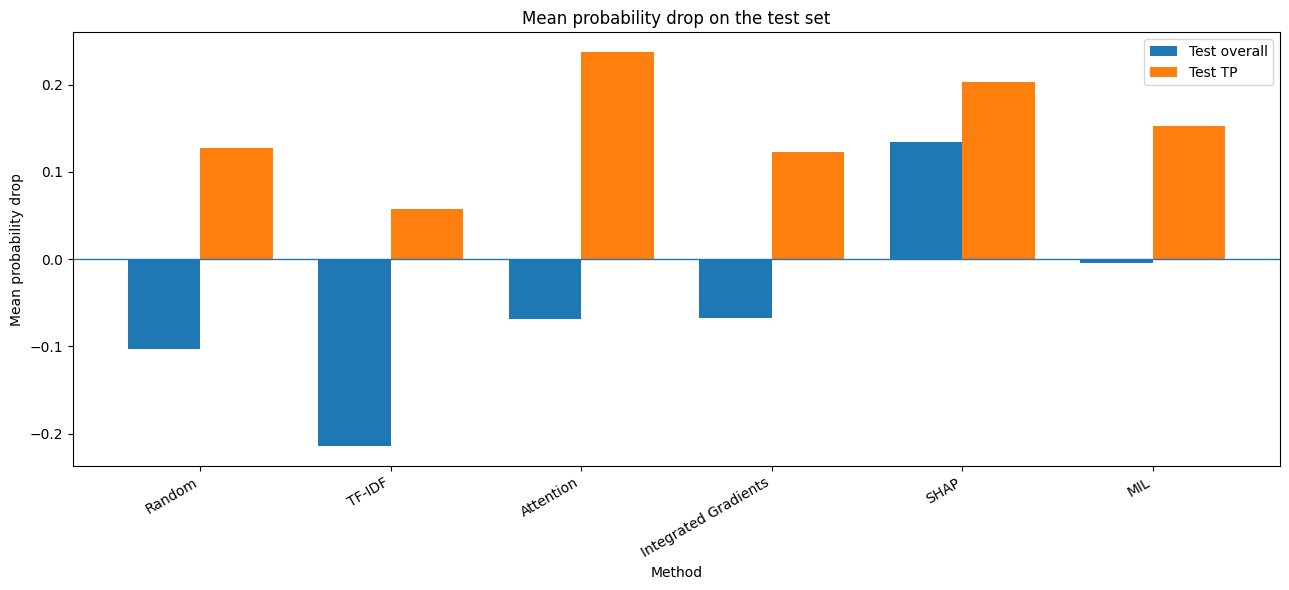

In [75]:
mean_pivot = (
    plot_summary
    .pivot(
        index="method",
        columns="subset",
        values="mean_probability_drop",
    )
    .reindex(METHOD_ORDER)
    .reindex(columns=SUBSET_ORDER)
)

lower_pivot = (
    plot_summary
    .pivot(
        index="method",
        columns="subset",
        values="lower_probability_drop",
    )
    .reindex(METHOD_ORDER)
    .reindex(columns=SUBSET_ORDER)
)

upper_pivot = (
    plot_summary
    .pivot(
        index="method",
        columns="subset",
        values="upper_probability_drop",
    )
    .reindex(METHOD_ORDER)
    .reindex(columns=SUBSET_ORDER)
)


x_positions = np.arange(
    len(METHOD_ORDER)
)

bar_width = 0.38


fig, ax = plt.subplots(
    figsize=(13, 6),
)


for subset_index, subset_name in enumerate(
    SUBSET_ORDER
):
    means = mean_pivot[
        subset_name
    ].to_numpy(dtype=float)

    lower_values = lower_pivot[
        subset_name
    ].to_numpy(dtype=float)

    upper_values = upper_pivot[
        subset_name
    ].to_numpy(dtype=float)

    lower_errors = means - lower_values
    upper_errors = upper_values - means

    offset = (
        subset_index
        - (len(SUBSET_ORDER) - 1) / 2
    ) * bar_width

    ax.bar(
        x_positions + offset,
        means,
        width=bar_width,
        label=subset_name,
        # yerr=np.vstack([
        #     lower_errors,
        #     upper_errors,
        # ]),
        capsize=5,
        error_kw={
            "ecolor": "black",
            "elinewidth": 1.5,
            "capthick": 1.5,
        },
    )


ax.axhline(
    0,
    linewidth=1,
)

ax.set_xticks(x_positions)

ax.set_xticklabels(
    [
        method_label(method)
        for method in METHOD_ORDER
    ],
    rotation=30,
    ha="right",
)

ax.set_xlabel(
    "Method"
)

ax.set_ylabel(
    "Mean probability drop"
)

ax.set_title(
    "Mean probability drop on the test set"
)

ax.legend()

fig.tight_layout()

save_figure(
    fig,
    "mean_probability_drop_test_overall_vs_tp",
)

plt.show()

/var/folders/9c/mdcbw50d74b4v7yjj79xw8yh0000gn/T/ipykernel_9214/710254545.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


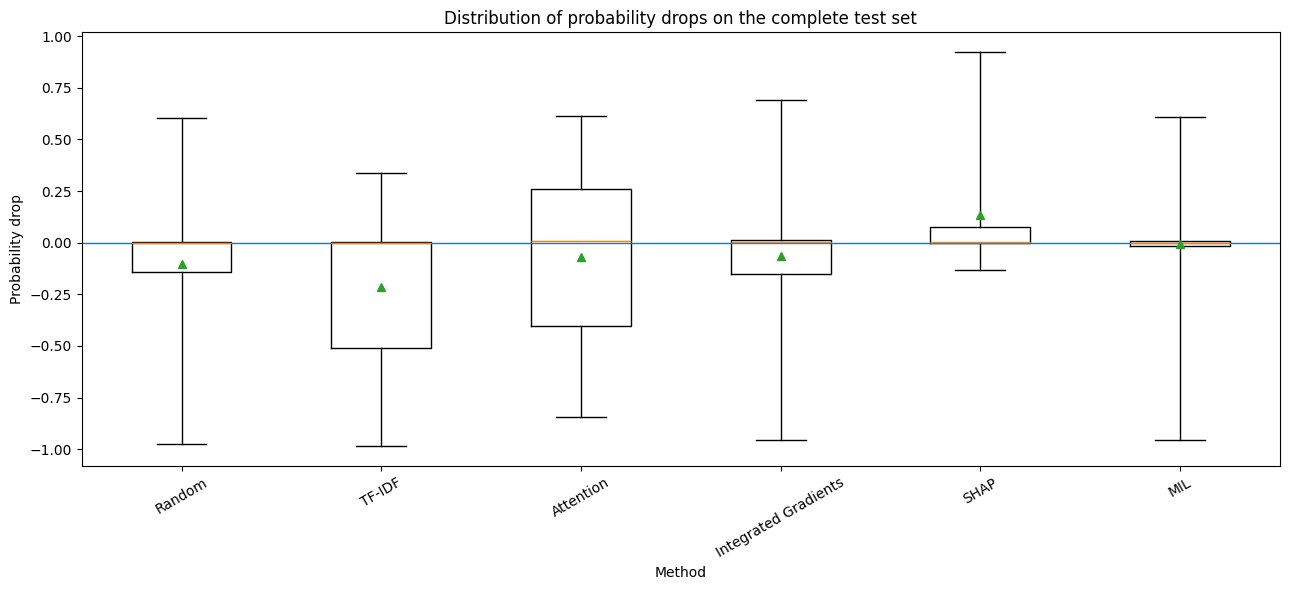

In [76]:
plot_probability_drop_boxplot(
    test_arguments,
    title=(
        "Distribution of probability drops "
        "on the complete test set"
    ),
    filename="probability_drop_boxplot_test_overall",
)

/var/folders/9c/mdcbw50d74b4v7yjj79xw8yh0000gn/T/ipykernel_9214/710254545.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


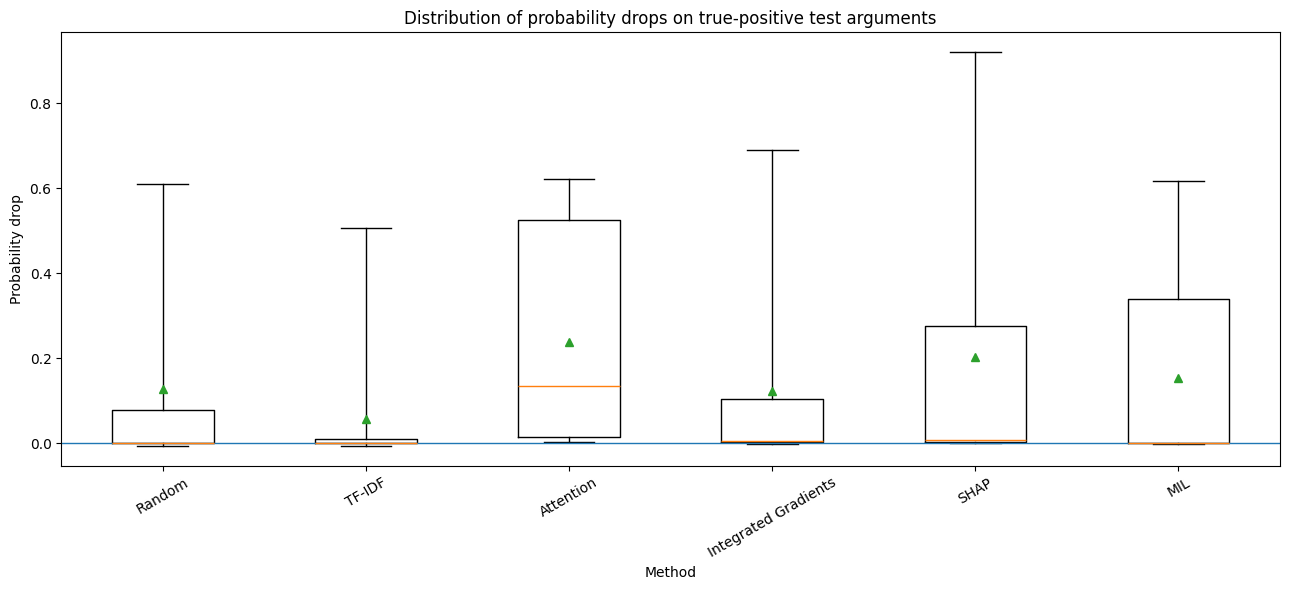

In [77]:
plot_probability_drop_boxplot(
    test_arguments.loc[
        test_arguments["confusion_type"].eq("TP")
    ],
    title=(
        "Distribution of probability drops "
        "on true-positive test arguments"
    ),
    filename="probability_drop_boxplot_test_tp",
)

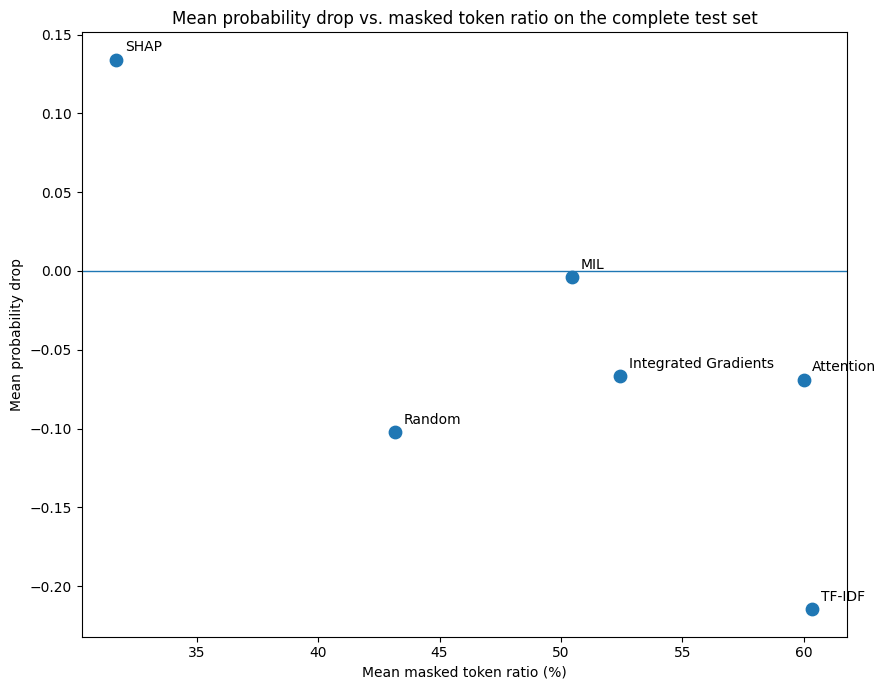

In [78]:
plot_drop_vs_masked_ratio(
    plot_summary,
    subset_name="Test overall",
    title=(
        "Mean probability drop vs. masked token ratio "
        "on the complete test set"
    ),
    filename=(
        "mean_probability_drop_vs_masked_ratio_"
        "test_overall"
    ),
)

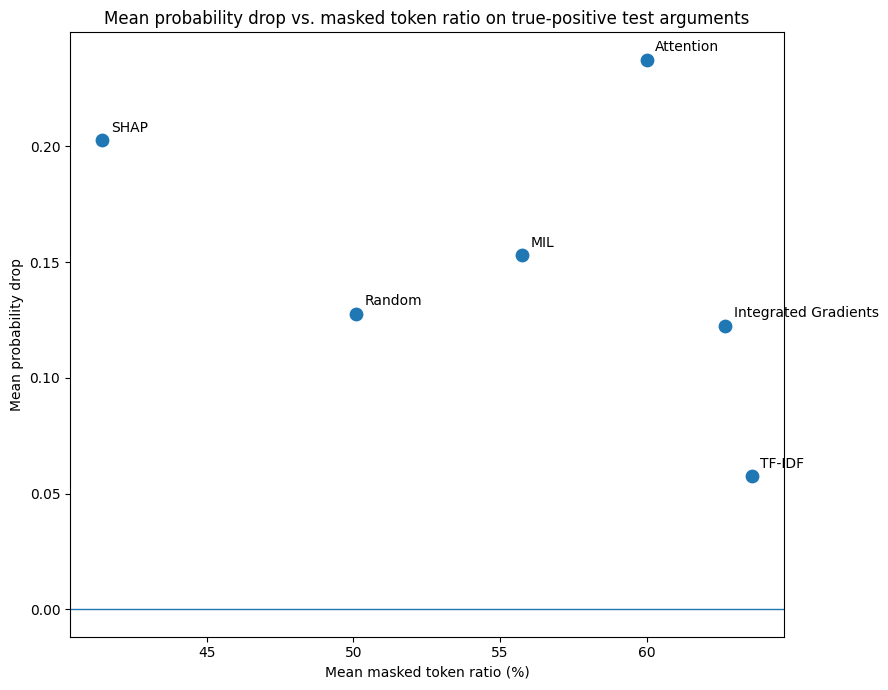

In [79]:
plot_drop_vs_masked_ratio(
    plot_summary,
    subset_name="Test TP",
    title=(
        "Mean probability drop vs. masked token ratio "
        "on true-positive test arguments"
    ),
    filename=(
        "mean_probability_drop_vs_masked_ratio_"
        "test_tp"
    ),
)

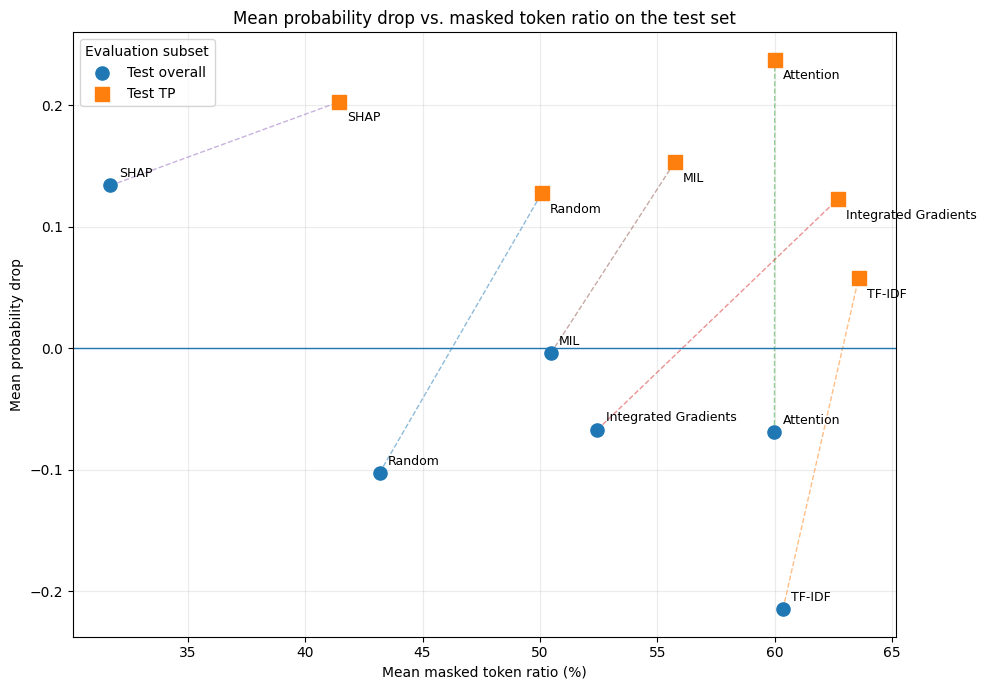

In [80]:
# ---------------------------------------------------------------------
# Mean probability drop vs. mean masked token ratio
# Test overall and Test TP in one plot
# ---------------------------------------------------------------------

current = (
    plot_summary
    .loc[
        plot_summary["subset"].isin([
            "Test overall",
            "Test TP",
        ])
    ]
    .copy()
)

current["method"] = current["method"].astype(str)

current["masked_token_percentage"] = (
    current["mean_masked_token_ratio"] * 100
)


# Use two colors from Matplotlib's default color cycle.
default_colors = (
    plt.rcParams["axes.prop_cycle"]
    .by_key()["color"]
)

subset_styles = {
    "Test overall": {
        "color": default_colors[0],
        "marker": "o",
        "annotation_offset": (6, 6),
    },
    "Test TP": {
        "color": default_colors[1],
        "marker": "s",
        "annotation_offset": (6, -14),
    },
}


fig, ax = plt.subplots(
    figsize=(10, 7),
)


# Connect overall and TP results belonging to the same method.
for method in METHOD_ORDER:
    method_data = (
        current
        .loc[current["method"].eq(method)]
        .set_index("subset")
        .reindex(SUBSET_ORDER)
        .dropna(
            subset=[
                "mean_masked_token_ratio",
                "mean_probability_drop",
            ]
        )
    )

    if len(method_data) == 2:
        ax.plot(
            method_data[
                "masked_token_percentage"
            ],
            method_data[
                "mean_probability_drop"
            ],
            linestyle="--",
            linewidth=1,
            alpha=0.5,
        )


# Plot the two subsets in different colors.
for subset_name in SUBSET_ORDER:
    subset = (
        current
        .loc[current["subset"].eq(subset_name)]
        .copy()
    )

    style = subset_styles[subset_name]

    ax.scatter(
        subset["masked_token_percentage"],
        subset["mean_probability_drop"],
        s=90,
        marker=style["marker"],
        color=style["color"],
        label=subset_name,
        zorder=3,
    )

    for row in subset.itertuples():
        ax.annotate(
            method_label(row.method),
            (
                row.masked_token_percentage,
                row.mean_probability_drop,
            ),
            xytext=style["annotation_offset"],
            textcoords="offset points",
            fontsize=9,
        )


ax.axhline(
    0,
    linewidth=1,
)

ax.set_xlabel(
    "Mean masked token ratio (%)"
)

ax.set_ylabel(
    "Mean probability drop"
)

ax.set_title(
    "Mean probability drop vs. masked token ratio "
    "on the test set"
)

ax.legend(
    title="Evaluation subset"
)

ax.grid(
    alpha=0.25,
)

fig.tight_layout()

save_figure(
    fig,
    "mean_probability_drop_vs_masked_ratio_test_overall_and_tp",
)

plt.show()

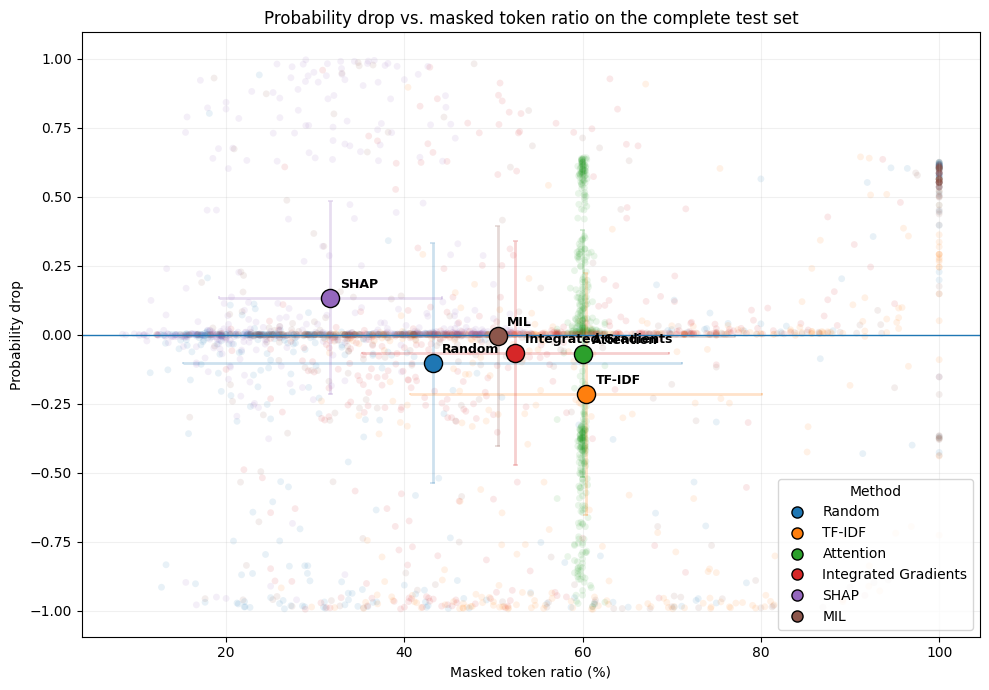

In [81]:
plot_drop_vs_masked_ratio_single_subset(
    argument_df=test_arguments,
    summary_df=plot_summary,
    subset_name="Test overall",
    title=(
        "Probability drop vs. masked token ratio "
        "on the complete test set"
    ),
    filename=(
        "probability_drop_vs_masked_ratio_"
        "test_overall_with_distribution"
    ),
    raw_point_alpha=0.10,
    std_alpha=0.22,
)

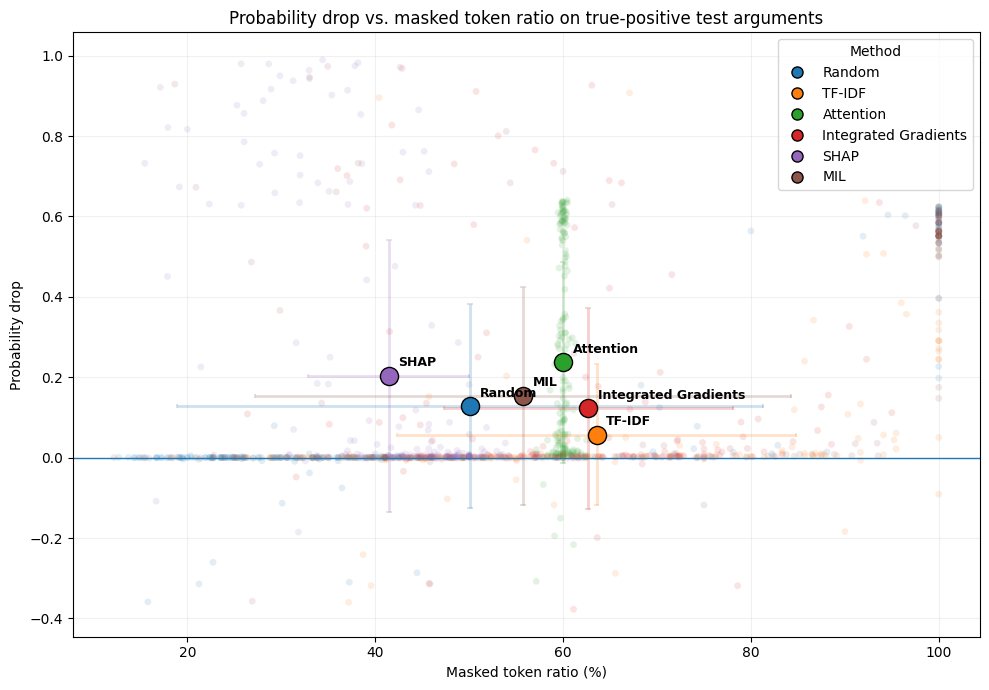

In [82]:
plot_drop_vs_masked_ratio_single_subset(
    argument_df=test_arguments,
    summary_df=plot_summary,
    subset_name="Test TP",
    title=(
        "Probability drop vs. masked token ratio "
        "on true-positive test arguments"
    ),
    filename=(
        "probability_drop_vs_masked_ratio_"
        "test_tp_with_distribution"
    ),
    raw_point_alpha=0.13,
    std_alpha=0.22,
)

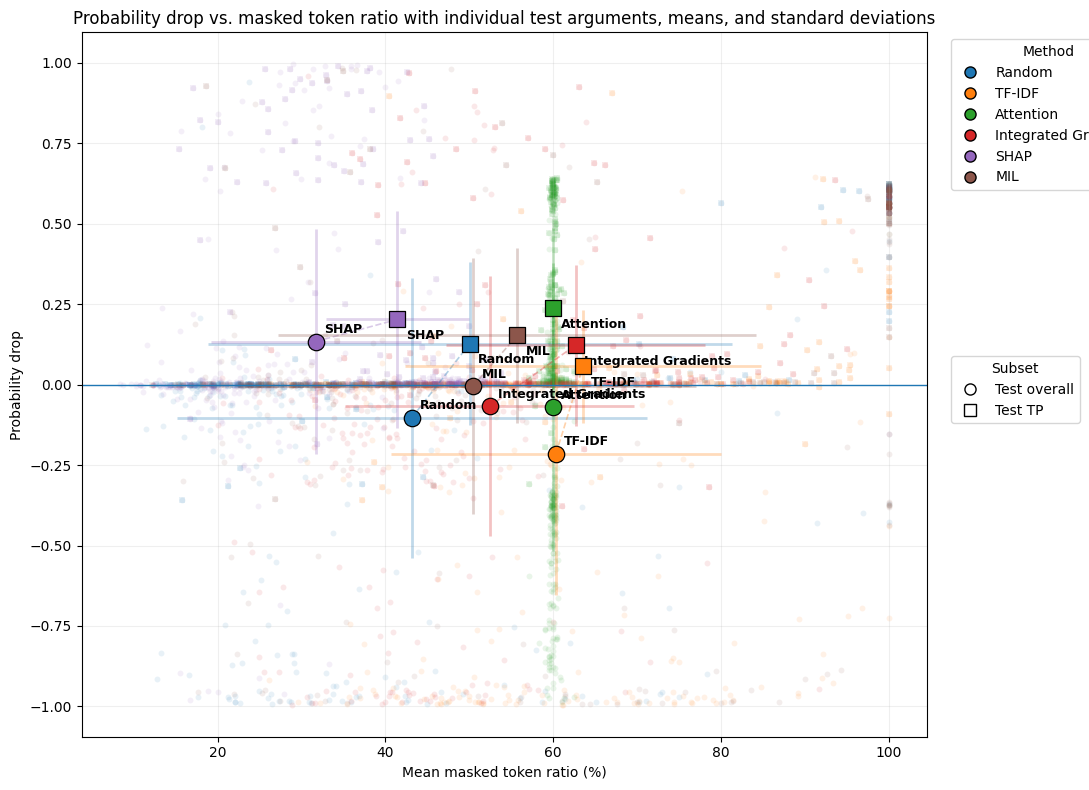

In [83]:
plot_drop_vs_masked_ratio_with_std(
    argument_df=test_arguments,
    summary_df=plot_summary,
    title=(
        "Probability drop vs. masked token ratio "
        "with individual test arguments, means, and standard deviations"
    ),
    filename="probability_drop_vs_masked_ratio_with_std",
)

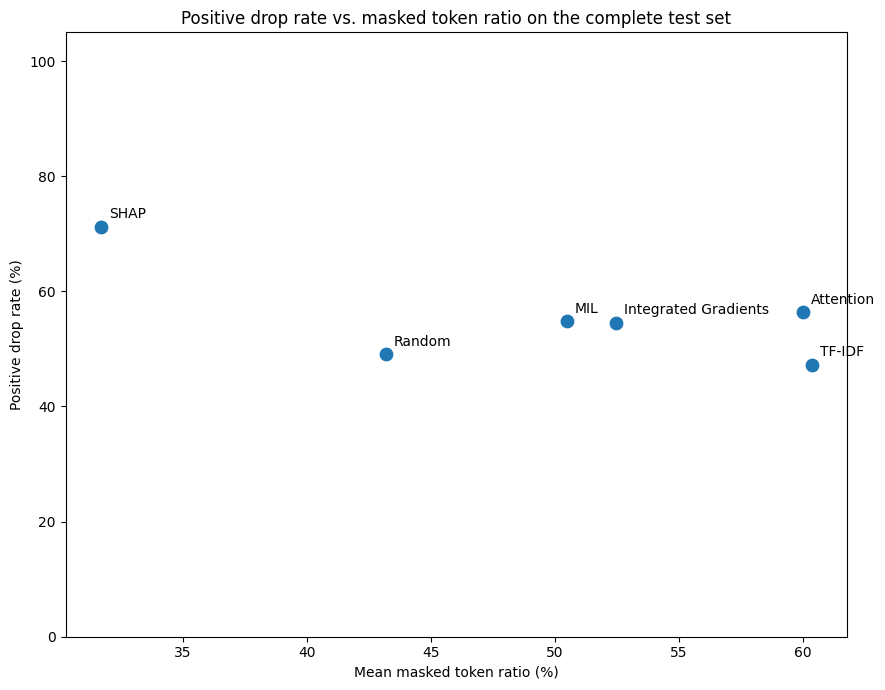

In [84]:
plot_positive_drop_rate_vs_masked_ratio(
    plot_summary,
    subset_name="Test overall",
    title=(
        "Positive drop rate vs. masked token ratio "
        "on the complete test set"
    ),
    filename=(
        "positive_drop_rate_vs_masked_ratio_"
        "test_overall"
    ),
)

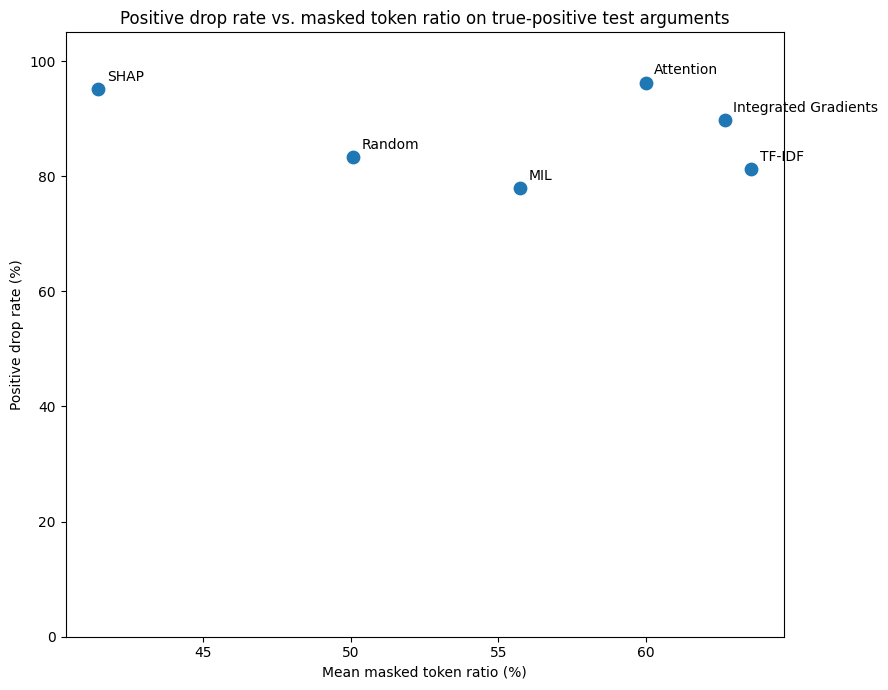

In [85]:
plot_positive_drop_rate_vs_masked_ratio(
    plot_summary,
    subset_name="Test TP",
    title=(
        "Positive drop rate vs. masked token ratio "
        "on true-positive test arguments"
    ),
    filename=(
        "positive_drop_rate_vs_masked_ratio_"
        "test_tp"
    ),
)

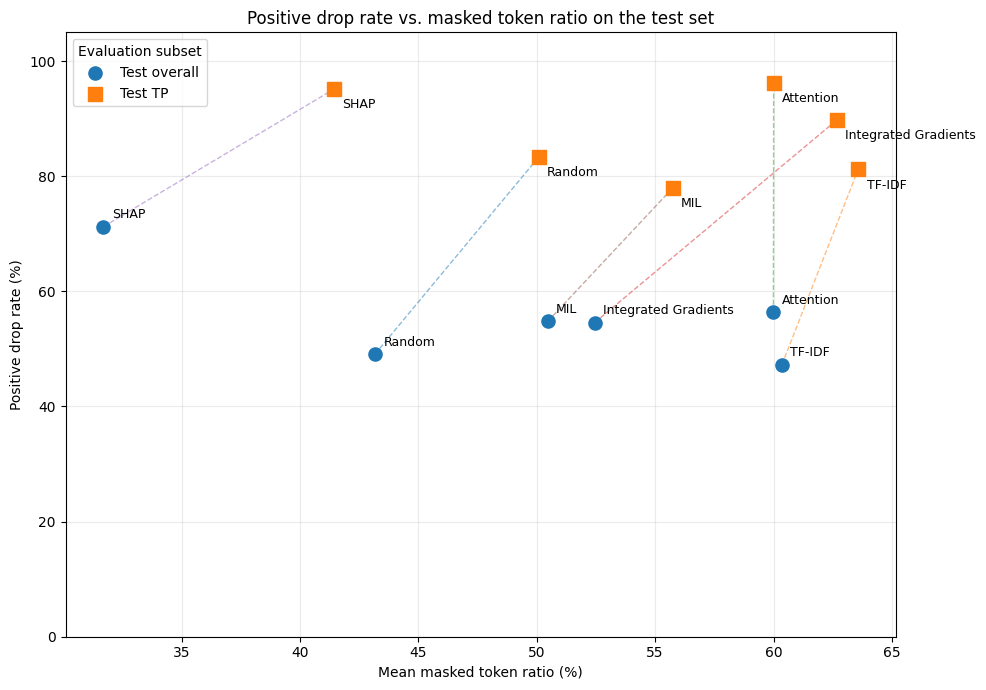

In [86]:
# ---------------------------------------------------------------------
# Positive drop rate vs. mean masked token ratio
# Test overall and Test TP in one plot
# ---------------------------------------------------------------------

current = (
    plot_summary
    .loc[
        plot_summary["subset"].isin([
            "Test overall",
            "Test TP",
        ])
    ]
    .copy()
)

current["method"] = current["method"].astype(str)

current["masked_token_percentage"] = (
    current["mean_masked_token_ratio"] * 100
)

current["positive_drop_percentage"] = (
    current["positive_drop_rate"] * 100
)


default_colors = (
    plt.rcParams["axes.prop_cycle"]
    .by_key()["color"]
)

subset_styles = {
    "Test overall": {
        "color": default_colors[0],
        "marker": "o",
        "annotation_offset": (6, 6),
    },
    "Test TP": {
        "color": default_colors[1],
        "marker": "s",
        "annotation_offset": (6, -14),
    },
}


fig, ax = plt.subplots(
    figsize=(10, 7),
)


# Connect overall and TP results belonging to the same method.
for method in METHOD_ORDER:
    method_data = (
        current
        .loc[current["method"].eq(method)]
        .set_index("subset")
        .reindex(SUBSET_ORDER)
        .dropna(
            subset=[
                "masked_token_percentage",
                "positive_drop_percentage",
            ]
        )
    )

    if len(method_data) == 2:
        ax.plot(
            method_data[
                "masked_token_percentage"
            ],
            method_data[
                "positive_drop_percentage"
            ],
            linestyle="--",
            linewidth=1,
            alpha=0.5,
        )


# Plot overall and TP with distinct colors.
for subset_name in SUBSET_ORDER:
    subset = (
        current
        .loc[current["subset"].eq(subset_name)]
        .copy()
    )

    style = subset_styles[subset_name]

    ax.scatter(
        subset["masked_token_percentage"],
        subset["positive_drop_percentage"],
        s=90,
        marker=style["marker"],
        color=style["color"],
        label=subset_name,
        zorder=3,
    )

    for row in subset.itertuples():
        ax.annotate(
            method_label(row.method),
            (
                row.masked_token_percentage,
                row.positive_drop_percentage,
            ),
            xytext=style["annotation_offset"],
            textcoords="offset points",
            fontsize=9,
        )


ax.set_xlabel(
    "Mean masked token ratio (%)"
)

ax.set_ylabel(
    "Positive drop rate (%)"
)

ax.set_title(
    "Positive drop rate vs. masked token ratio "
    "on the test set"
)

ax.set_ylim(
    0,
    105,
)

ax.legend(
    title="Evaluation subset"
)

ax.grid(
    alpha=0.25,
)

fig.tight_layout()

save_figure(
    fig,
    "positive_drop_rate_vs_masked_ratio_test_overall_and_tp",
)

plt.show()

# Improvement vs Random Baseline

In [87]:
RANDOM_METHOD = "random"

random_reference = (
    plot_summary
    .loc[
        plot_summary["method"].astype(str).eq(
            RANDOM_METHOD
        ),
        [
            "subset",
            "mean_probability_drop",
            "positive_drop_rate",
        ],
    ]
    .rename(columns={
        "mean_probability_drop": (
            "random_mean_probability_drop"
        ),
        "positive_drop_rate": (
            "random_positive_drop_rate"
        ),
    })
)


improvement_vs_random = (
    plot_summary
    .merge(
        random_reference,
        on="subset",
        how="left",
    )
    .copy()
)


improvement_vs_random[
    "mean_probability_drop_difference"
] = (
    improvement_vs_random[
        "mean_probability_drop"
    ]
    - improvement_vs_random[
        "random_mean_probability_drop"
    ]
)


improvement_vs_random[
    "positive_drop_rate_difference"
] = (
    improvement_vs_random[
        "positive_drop_rate"
    ]
    - improvement_vs_random[
        "random_positive_drop_rate"
    ]
)


improvement_vs_random.to_csv(
    TABLE_DIR / "improvement_vs_random.csv",
    index=False,
)


display(
    improvement_vs_random[
        [
            "method",
            "subset",
            "mean_probability_drop_difference",
            "positive_drop_rate_difference",
        ]
    ]
    .style
    .format({
        "mean_probability_drop_difference": "{:+.4f}",
        "positive_drop_rate_difference": "{:+.2%}",
    })
)

,method,subset,mean_probability_drop_difference,positive_drop_rate_difference
0,random,Test overall,+0.0000,+0.00%
1,random,Test TP,+0.0000,+0.00%
2,tfidf,Test overall,-0.1121,-1.83%
3,tfidf,Test TP,-0.0702,-2.15%
4,attention,Test overall,+0.0335,+7.31%
5,attention,Test TP,+0.1097,+12.90%
6,ig,Test overall,+0.0355,+5.48%
7,ig,Test TP,-0.0051,+6.45%
8,shap,Test overall,+0.2365,+22.15%
9,shap,Test TP,+0.0751,+11.83%


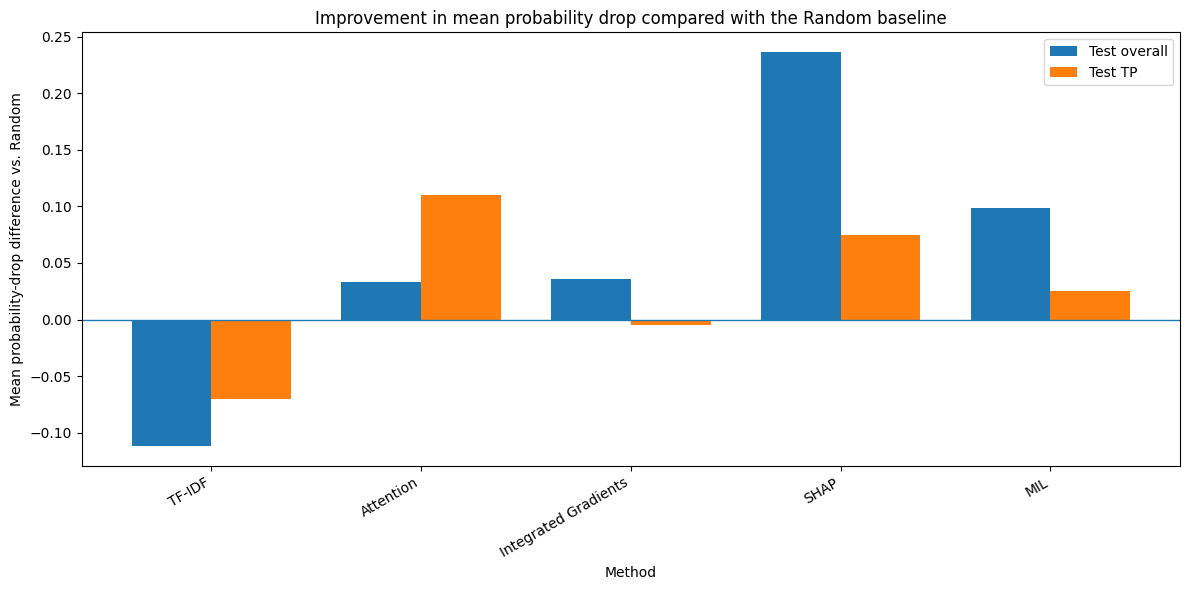

In [88]:
mean_improvement_df = (
    improvement_vs_random
    .loc[
        ~improvement_vs_random[
            "method"
        ].astype(str).eq(RANDOM_METHOD)
    ]
    .copy()
)


comparison_methods = [
    method
    for method in METHOD_ORDER
    if method != RANDOM_METHOD
]


mean_improvement_pivot = (
    mean_improvement_df
    .pivot(
        index="method",
        columns="subset",
        values="mean_probability_drop_difference",
    )
    .reindex(comparison_methods)
    .reindex(columns=SUBSET_ORDER)
)


x_positions = np.arange(
    len(comparison_methods)
)

bar_width = 0.38


fig, ax = plt.subplots(
    figsize=(12, 6),
)


for subset_index, subset_name in enumerate(
    SUBSET_ORDER
):
    offset = (
        subset_index
        - (len(SUBSET_ORDER) - 1) / 2
    ) * bar_width

    ax.bar(
        x_positions + offset,
        mean_improvement_pivot[
            subset_name
        ].to_numpy(dtype=float),
        width=bar_width,
        label=subset_name,
    )


ax.axhline(
    0,
    linewidth=1,
)

ax.set_xticks(x_positions)

ax.set_xticklabels(
    [
        method_label(method)
        for method in comparison_methods
    ],
    rotation=30,
    ha="right",
)

ax.set_xlabel(
    "Method"
)

ax.set_ylabel(
    "Mean probability-drop difference vs. Random"
)

ax.set_title(
    "Improvement in mean probability drop "
    "compared with the Random baseline"
)

ax.legend()

fig.tight_layout()

save_figure(
    fig,
    "mean_probability_drop_improvement_vs_random",
)

plt.show()

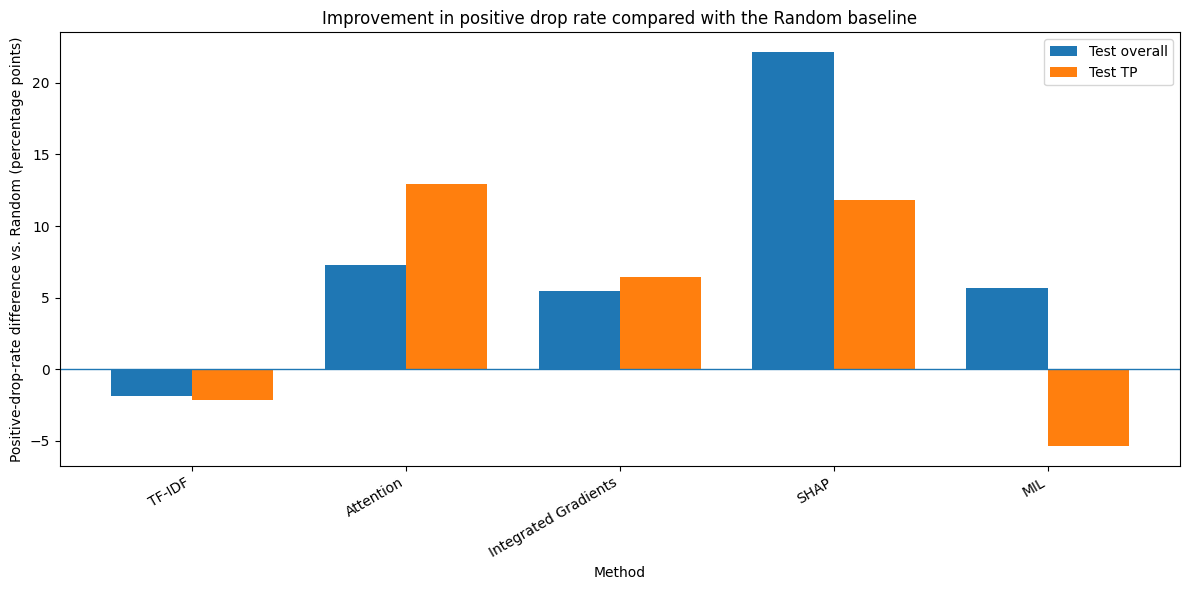

In [89]:
positive_rate_improvement_pivot = (
    mean_improvement_df
    .pivot(
        index="method",
        columns="subset",
        values="positive_drop_rate_difference",
    )
    .reindex(comparison_methods)
    .reindex(columns=SUBSET_ORDER)
    * 100
)


x_positions = np.arange(
    len(comparison_methods)
)

bar_width = 0.38


fig, ax = plt.subplots(
    figsize=(12, 6),
)


for subset_index, subset_name in enumerate(
    SUBSET_ORDER
):
    offset = (
        subset_index
        - (len(SUBSET_ORDER) - 1) / 2
    ) * bar_width

    ax.bar(
        x_positions + offset,
        positive_rate_improvement_pivot[
            subset_name
        ].to_numpy(dtype=float),
        width=bar_width,
        label=subset_name,
    )


ax.axhline(
    0,
    linewidth=1,
)

ax.set_xticks(x_positions)

ax.set_xticklabels(
    [
        method_label(method)
        for method in comparison_methods
    ],
    rotation=30,
    ha="right",
)

ax.set_xlabel(
    "Method"
)

ax.set_ylabel(
    "Positive-drop-rate difference "
    "vs. Random (percentage points)"
)

ax.set_title(
    "Improvement in positive drop rate "
    "compared with the Random baseline"
)

ax.legend()

fig.tight_layout()

save_figure(
    fig,
    "positive_drop_rate_improvement_vs_random",
)

plt.show()

In [90]:
evaluation_table = (
    plot_summary
    .copy()
)


evaluation_table["method_label"] = (
    evaluation_table["method"]
    .astype(str)
    .map(method_label)
)


evaluation_table = evaluation_table[
    [
        "method_label",
        "subset",
        "n_arguments",
        "mean_probability_drop",
        "std_probability_drop",
        "median_probability_drop",
        "positive_drop_rate",
        "mean_masked_token_ratio",
        "std_masked_token_ratio",
    ]
]


evaluation_table.to_csv(
    TABLE_DIR / "methods_vs_baselines_evaluation.csv",
    index=False,
)


display(
    evaluation_table.style.format({
        "mean_probability_drop": "{:.4f}",
        "std_probability_drop": "{:.4f}",
        "median_probability_drop": "{:.4f}",
        "positive_drop_rate": "{:.2%}",
        "mean_masked_token_ratio": "{:.2%}",
        "std_masked_token_ratio": "{:.2%}",
    })
)

,method_label,subset,n_arguments,mean_probability_drop,std_probability_drop,median_probability_drop,positive_drop_rate,mean_masked_token_ratio,std_masked_token_ratio
0,Random,Test overall,438,-0.1025,0.4347,-0.0002,49.09%,43.17%,28.02%
1,Random,Test TP,186,0.1277,0.2535,0.0008,83.33%,50.08%,31.19%
2,TF-IDF,Test overall,438,-0.2146,0.4382,-0.0003,47.26%,60.35%,19.72%
3,TF-IDF,Test TP,186,0.0575,0.1756,0.0011,81.18%,63.57%,21.25%
4,Attention,Test overall,438,-0.0691,0.4471,0.0093,56.39%,59.99%,0.64%
5,Attention,Test TP,186,0.2373,0.2501,0.1342,96.24%,60.00%,0.79%
6,Integrated Gradients,Test overall,438,-0.0670,0.4047,0.0013,54.57%,52.45%,17.21%
7,Integrated Gradients,Test TP,186,0.1225,0.2499,0.0057,89.78%,62.68%,15.40%
8,SHAP,Test overall,438,0.1339,0.3499,0.0034,71.23%,31.70%,12.51%
9,SHAP,Test TP,186,0.2027,0.3382,0.0067,95.16%,41.45%,8.56%


## Flip Rate

In [91]:
# ---------------------------------------------------------------------
# Prediction flip summary
# ---------------------------------------------------------------------

flip_summary_table = (
    plot_summary[
        [
            "method",
            "subset",
            "n_arguments",
            "flip_rate",
            "flip_to_appropriate_rate",
            "flip_to_inappropriate_rate",
        ]
    ]
    .copy()
)


flip_summary_table["method_label"] = (
    flip_summary_table["method"]
    .astype(str)
    .map(method_label)
)


display(
    flip_summary_table[
        [
            "method_label",
            "subset",
            "n_arguments",
            "flip_rate",
            "flip_to_appropriate_rate",
            "flip_to_inappropriate_rate",
        ]
    ]
    .style
    .format({
        "flip_rate": "{:.1%}",
        "flip_to_appropriate_rate": "{:.1%}",
        "flip_to_inappropriate_rate": "{:.1%}",
    })
)


flip_summary_table.to_csv(
    TABLE_DIR / "prediction_flip_summary.csv",
    index=False,
)

,method_label,subset,n_arguments,flip_rate,flip_to_appropriate_rate,flip_to_inappropriate_rate
0,Random,Test overall,438,31.7%,23.3%,43.6%
1,Random,Test TP,186,23.7%,23.7%,nan%
2,TF-IDF,Test overall,438,29.7%,7.0%,61.9%
3,TF-IDF,Test TP,186,5.9%,5.9%,nan%
4,Attention,Test overall,438,37.0%,31.9%,44.2%
5,Attention,Test TP,186,29.6%,29.6%,nan%
6,Integrated Gradients,Test overall,438,24.4%,17.5%,34.3%
7,Integrated Gradients,Test TP,186,15.1%,15.1%,nan%
8,SHAP,Test overall,438,19.6%,30.0%,5.0%
9,SHAP,Test TP,186,23.7%,23.7%,nan%


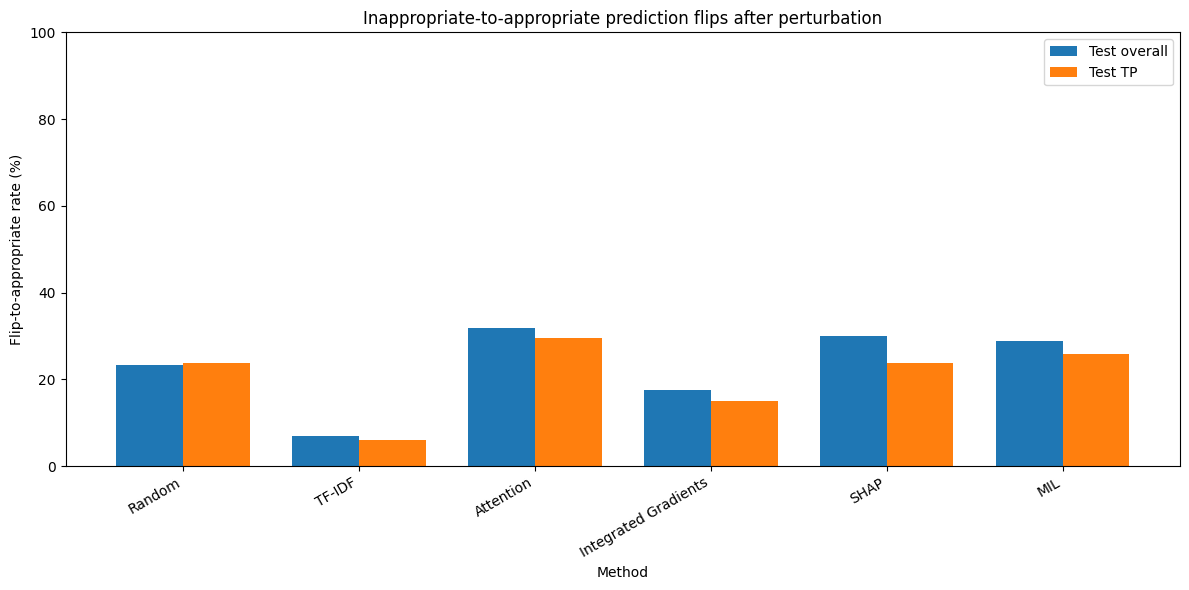

In [92]:
# ---------------------------------------------------------------------
# Flip from inappropriate -> appropriate
#
# Denominator:
# only arguments originally predicted as inappropriate.
# ---------------------------------------------------------------------

flip_to_appropriate_pivot = (
    plot_summary
    .pivot(
        index="method",
        columns="subset",
        values="flip_to_appropriate_rate",
    )
    .reindex(METHOD_ORDER)
    .reindex(columns=SUBSET_ORDER)
)


x_positions = np.arange(
    len(METHOD_ORDER)
)

bar_width = 0.38


fig, ax = plt.subplots(
    figsize=(12, 6),
)


for subset_index, subset_name in enumerate(
    SUBSET_ORDER
):
    offset = (
        subset_index
        - (len(SUBSET_ORDER) - 1) / 2
    ) * bar_width

    ax.bar(
        x_positions + offset,
        (
            flip_to_appropriate_pivot[
                subset_name
            ].to_numpy(dtype=float)
            * 100
        ),
        width=bar_width,
        label=subset_name,
    )


ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    [
        method_label(method)
        for method in METHOD_ORDER
    ],
    rotation=30,
    ha="right",
)

ax.set_xlabel(
    "Method"
)

ax.set_ylabel(
    "Flip-to-appropriate rate (%)"
)

ax.set_title(
    "Inappropriate-to-appropriate prediction flips "
    "after perturbation"
)

ax.set_ylim(
    0,
    100,
)

ax.legend()

fig.tight_layout()

save_figure(
    fig,
    "flip_to_appropriate_rate_test_overall_vs_tp",
)

plt.show()

# Statistical tests

In [93]:
def get_paired_values(
    df: pd.DataFrame,
    method: str,
    baseline: str,
    metric: str,
) -> pd.DataFrame:
    """
    Return paired argument-level values for one method and baseline.

    Only arguments for which both methods have a valid value are kept.
    """
    paired = (
        df.loc[
            df["method"].isin([
                method,
                baseline,
            ]),
            [
                "global_row_id",
                "method",
                metric,
            ],
        ]
        .dropna(subset=[metric])
        .pivot_table(
            index="global_row_id",
            columns="method",
            values=metric,
            aggfunc="first",
        )
    )

    required_columns = {
        method,
        baseline,
    }

    if not required_columns.issubset(
        paired.columns
    ):
        return pd.DataFrame(
            columns=[
                baseline,
                method,
            ]
        )

    paired = (
        paired[
            [
                baseline,
                method,
            ]
        ]
        .dropna()
        .copy()
    )

    return paired

In [94]:
def paired_bootstrap_mean_ci(
    differences,
    *,
    n_bootstrap: int = N_BOOTSTRAP,
    confidence: float = BOOTSTRAP_CONFIDENCE,
    seed: int = STAT_RANDOM_SEED,
) -> tuple[float, float, float]:
    """
    Percentile bootstrap CI for the mean of paired differences.

    Parameters
    ----------
    differences:
        Array of paired differences:
        method_value - baseline_value.

    Returns
    -------
    mean_difference, ci_lower, ci_upper
    """
    differences = np.asarray(
        differences,
        dtype=float,
    )

    differences = differences[
        np.isfinite(differences)
    ]

    if len(differences) == 0:
        return np.nan, np.nan, np.nan

    observed_mean = differences.mean()

    if len(differences) == 1:
        return (
            observed_mean,
            observed_mean,
            observed_mean,
        )

    rng = np.random.default_rng(seed)

    bootstrap_means = np.empty(
        n_bootstrap,
        dtype=float,
    )

    for bootstrap_index in range(
        n_bootstrap
    ):
        sampled_indices = rng.integers(
            low=0,
            high=len(differences),
            size=len(differences),
        )

        bootstrap_means[
            bootstrap_index
        ] = (
            differences[
                sampled_indices
            ].mean()
        )

    alpha = 1.0 - confidence

    ci_lower = np.quantile(
        bootstrap_means,
        alpha / 2,
    )

    ci_upper = np.quantile(
        bootstrap_means,
        1 - alpha / 2,
    )

    return (
        observed_mean,
        ci_lower,
        ci_upper,
    )

In [95]:
def paired_rank_biserial(
    differences,
) -> float:
    """
    Rank-biserial correlation for paired differences.

    Positive:
        method tends to have higher values than baseline.

    Negative:
        baseline tends to have higher values than method.

    Range:
        [-1, 1]
    """
    differences = np.asarray(
        differences,
        dtype=float,
    )

    differences = differences[
        np.isfinite(differences)
    ]

    # Wilcoxon ignores exact zero differences.
    nonzero = differences[
        differences != 0
    ]

    if len(nonzero) == 0:
        return 0.0

    ranks = rankdata(
        np.abs(nonzero),
        method="average",
    )

    positive_rank_sum = ranks[
        nonzero > 0
    ].sum()

    negative_rank_sum = ranks[
        nonzero < 0
    ].sum()

    total_rank_sum = (
        positive_rank_sum
        + negative_rank_sum
    )

    if total_rank_sum == 0:
        return 0.0

    return (
        positive_rank_sum
        - negative_rank_sum
    ) / total_rank_sum

In [96]:
def holm_adjust(
    p_values,
) -> np.ndarray:
    """
    Holm correction for multiple comparisons.
    """
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    adjusted = np.full(
        len(p_values),
        np.nan,
        dtype=float,
    )

    valid_mask = np.isfinite(
        p_values
    )

    valid_p = p_values[
        valid_mask
    ]

    if len(valid_p) == 0:
        return adjusted

    order = np.argsort(
        valid_p
    )

    sorted_p = valid_p[
        order
    ]

    n_tests = len(sorted_p)

    sorted_adjusted = np.empty(
        n_tests,
        dtype=float,
    )

    running_max = 0.0

    for index, p_value in enumerate(
        sorted_p
    ):
        multiplier = (
            n_tests - index
        )

        corrected = min(
            1.0,
            multiplier * p_value,
        )

        corrected = max(
            corrected,
            running_max,
        )

        sorted_adjusted[index] = (
            corrected
        )

        running_max = corrected

    inverse_order = np.empty_like(
        order
    )

    inverse_order[
        order
    ] = np.arange(
        n_tests
    )

    adjusted_valid = (
        sorted_adjusted[
            inverse_order
        ]
    )

    adjusted[
        valid_mask
    ] = adjusted_valid

    return adjusted

In [97]:
# ---------------------------------------------------------------------
# Probability-drop comparisons
# ---------------------------------------------------------------------

prob_drop_rows = []

comparison_index = 0


for subset_name, subset_df in (
    STAT_SUBSETS.items()
):
    for baseline in STAT_BASELINES:
        for method in STAT_METHODS:

            paired = get_paired_values(
                subset_df,
                method=method,
                baseline=baseline,
                metric="prob_drop",
            )

            if paired.empty:
                continue

            method_values = (
                paired[method]
                .to_numpy(dtype=float)
            )

            baseline_values = (
                paired[baseline]
                .to_numpy(dtype=float)
            )

            differences = (
                method_values
                - baseline_values
            )

            # ------------------------------------------------------
            # Mean difference + paired bootstrap CI
            # ------------------------------------------------------

            (
                mean_difference,
                ci_lower,
                ci_upper,
            ) = paired_bootstrap_mean_ci(
                differences,
                seed=(
                    STAT_RANDOM_SEED
                    + comparison_index
                ),
            )

            # ------------------------------------------------------
            # Wilcoxon signed-rank test
            # ------------------------------------------------------

            if np.allclose(
                differences,
                0,
            ):
                wilcoxon_statistic = 0.0
                wilcoxon_p = 1.0

            else:
                wilcoxon_result = wilcoxon(
                    differences,
                    zero_method="wilcox",
                    alternative="two-sided",
                    method="auto",
                )

                wilcoxon_statistic = (
                    wilcoxon_result.statistic
                )

                wilcoxon_p = (
                    wilcoxon_result.pvalue
                )

            rank_biserial = (
                paired_rank_biserial(
                    differences
                )
            )

            prob_drop_rows.append({
                "subset": subset_name,
                "method": method,
                "baseline": baseline,

                "n_pairs": len(paired),

                "mean_method": (
                    method_values.mean()
                ),

                "mean_baseline": (
                    baseline_values.mean()
                ),

                "mean_difference": (
                    mean_difference
                ),

                "median_difference": (
                    np.median(differences)
                ),

                "ci_95_lower": ci_lower,
                "ci_95_upper": ci_upper,

                "wilcoxon_W": (
                    wilcoxon_statistic
                ),

                "wilcoxon_p": (
                    wilcoxon_p
                ),

                "rank_biserial": (
                    rank_biserial
                ),

                "method_wins": (
                    differences > 0
                ).mean(),

                "ties": (
                    differences == 0
                ).mean(),

                "baseline_wins": (
                    differences < 0
                ).mean(),
            })

            comparison_index += 1


prob_drop_statistics = pd.DataFrame(
    prob_drop_rows
)

In [98]:
prob_drop_statistics[
    "wilcoxon_p_holm"
] = np.nan


for subset_name in (
    prob_drop_statistics[
        "subset"
    ].unique()
):
    subset_mask = (
        prob_drop_statistics[
            "subset"
        ].eq(subset_name)
    )

    prob_drop_statistics.loc[
        subset_mask,
        "wilcoxon_p_holm",
    ] = holm_adjust(
        prob_drop_statistics.loc[
            subset_mask,
            "wilcoxon_p",
        ].to_numpy()
    )


prob_drop_statistics[
    "significant_holm_005"
] = (
    prob_drop_statistics[
        "wilcoxon_p_holm"
    ] < STAT_ALPHA
)


prob_drop_statistics.to_csv(
    TABLE_DIR
    / "statistical_prob_drop_vs_baselines.csv",
    index=False,
)

In [99]:
display(
    prob_drop_statistics[
        [
            "subset",
            "method",
            "baseline",
            "n_pairs",

            "mean_method",
            "mean_baseline",
            "mean_difference",

            "ci_95_lower",
            "ci_95_upper",

            "wilcoxon_p",
            "wilcoxon_p_holm",

            "rank_biserial",
            "method_wins",

            "significant_holm_005",
        ]
    ]
    .style
    .format({
        "mean_method": "{:.4f}",
        "mean_baseline": "{:.4f}",
        "mean_difference": "{:+.4f}",

        "ci_95_lower": "{:+.4f}",
        "ci_95_upper": "{:+.4f}",

        "wilcoxon_p": "{:.4g}",
        "wilcoxon_p_holm": "{:.4g}",

        "rank_biserial": "{:+.3f}",
        "method_wins": "{:.1%}",
    })
)

,subset,method,baseline,n_pairs,mean_method,mean_baseline,mean_difference,ci_95_lower,ci_95_upper,wilcoxon_p,wilcoxon_p_holm,rank_biserial,method_wins,significant_holm_005
0,Test overall,attention,random,438,-0.0691,-0.1025,+0.0335,-0.0065,+0.0729,0.02371,0.02868,+0.125,59.6%,True
1,Test overall,ig,random,438,-0.0670,-0.1025,+0.0355,-0.0046,+0.0734,0.01434,0.02868,+0.137,59.4%,True
2,Test overall,shap,random,438,0.1339,-0.1025,+0.2365,+0.1910,+0.2835,7.693e-26,5.385e-25,+0.580,76.7%,True
3,Test overall,mil,random,438,-0.0041,-0.1025,+0.0984,+0.0624,+0.1347,0.006797,0.02039,+0.149,47.9%,True
4,Test overall,attention,tfidf,438,-0.0691,-0.2146,+0.1456,+0.1116,+0.1795,7.9e-16,3.95e-15,+0.444,69.9%,True
5,Test overall,ig,tfidf,438,-0.0670,-0.2146,+0.1477,+0.1121,+0.1842,3.655e-15,1.462e-14,+0.436,68.5%,True
6,Test overall,shap,tfidf,438,0.1339,-0.2146,+0.3486,+0.3038,+0.3922,1.793e-39,1.434e-38,+0.725,79.5%,True
7,Test overall,mil,tfidf,438,-0.0041,-0.2146,+0.2106,+0.1742,+0.2478,1.144e-19,6.862e-19,+0.500,60.5%,True
8,Test TP,attention,random,186,0.2373,0.1277,+0.1097,+0.0482,+0.1692,1.99e-05,9.951e-05,+0.361,73.1%,True
9,Test TP,ig,random,186,0.1225,0.1277,-0.0051,-0.0560,+0.0457,0.011,0.022,+0.220,65.1%,True


In [100]:
def exact_mcnemar(
    method_positive,
    baseline_positive,
) -> dict:
    """
    Exact McNemar test using a two-sided binomial test.

    b:
        method positive, baseline not positive

    c:
        baseline positive, method not positive
    """
    method_positive = np.asarray(
        method_positive,
        dtype=bool,
    )

    baseline_positive = np.asarray(
        baseline_positive,
        dtype=bool,
    )

    method_only = int(
        np.sum(
            method_positive
            & ~baseline_positive
        )
    )

    baseline_only = int(
        np.sum(
            ~method_positive
            & baseline_positive
        )
    )

    n_discordant = (
        method_only
        + baseline_only
    )

    if n_discordant == 0:
        p_value = 1.0

    else:
        p_value = binomtest(
            k=method_only,
            n=n_discordant,
            p=0.5,
            alternative="two-sided",
        ).pvalue

    return {
        "method_only_positive": (
            method_only
        ),
        "baseline_only_positive": (
            baseline_only
        ),
        "n_discordant": (
            n_discordant
        ),
        "mcnemar_p": (
            p_value
        ),
    }

In [101]:
# ---------------------------------------------------------------------
# Positive-drop-rate comparisons
# ---------------------------------------------------------------------

pdr_rows = []

comparison_index = 0


for subset_name, subset_df in (
    STAT_SUBSETS.items()
):
    for baseline in STAT_BASELINES:
        for method in STAT_METHODS:

            paired = get_paired_values(
                subset_df,
                method=method,
                baseline=baseline,
                metric="prob_drop",
            )

            if paired.empty:
                continue

            method_positive = (
                paired[method]
                .to_numpy(dtype=float)
                > 0
            )

            baseline_positive = (
                paired[baseline]
                .to_numpy(dtype=float)
                > 0
            )

            method_rate = (
                method_positive.mean()
            )

            baseline_rate = (
                baseline_positive.mean()
            )

            binary_differences = (
                method_positive.astype(float)
                - baseline_positive.astype(float)
            )

            (
                pdr_difference,
                ci_lower,
                ci_upper,
            ) = paired_bootstrap_mean_ci(
                binary_differences,
                seed=(
                    STAT_RANDOM_SEED
                    + 10_000
                    + comparison_index
                ),
            )

            mcnemar_result = exact_mcnemar(
                method_positive,
                baseline_positive,
            )

            pdr_rows.append({
                "subset": subset_name,
                "method": method,
                "baseline": baseline,

                "n_pairs": len(paired),

                "positive_drop_rate_method": (
                    method_rate
                ),

                "positive_drop_rate_baseline": (
                    baseline_rate
                ),

                "pdr_difference": (
                    pdr_difference
                ),

                "pdr_difference_pp": (
                    pdr_difference * 100
                ),

                "ci_95_lower": (
                    ci_lower
                ),

                "ci_95_upper": (
                    ci_upper
                ),

                "ci_95_lower_pp": (
                    ci_lower * 100
                ),

                "ci_95_upper_pp": (
                    ci_upper * 100
                ),

                **mcnemar_result,
            })

            comparison_index += 1


pdr_statistics = pd.DataFrame(
    pdr_rows
)

In [102]:
pdr_statistics[
    "mcnemar_p_holm"
] = np.nan


for subset_name in (
    pdr_statistics[
        "subset"
    ].unique()
):
    subset_mask = (
        pdr_statistics[
            "subset"
        ].eq(subset_name)
    )

    pdr_statistics.loc[
        subset_mask,
        "mcnemar_p_holm",
    ] = holm_adjust(
        pdr_statistics.loc[
            subset_mask,
            "mcnemar_p",
        ].to_numpy()
    )


pdr_statistics[
    "significant_holm_005"
] = (
    pdr_statistics[
        "mcnemar_p_holm"
    ] < STAT_ALPHA
)


pdr_statistics.to_csv(
    TABLE_DIR
    / "statistical_positive_drop_rate_vs_baselines.csv",
    index=False,
)

In [103]:
display(
    pdr_statistics[
        [
            "subset",
            "method",
            "baseline",
            "n_pairs",

            "positive_drop_rate_method",
            "positive_drop_rate_baseline",

            "pdr_difference_pp",
            "ci_95_lower_pp",
            "ci_95_upper_pp",

            "method_only_positive",
            "baseline_only_positive",
            "n_discordant",

            "mcnemar_p",
            "mcnemar_p_holm",

            "significant_holm_005",
        ]
    ]
    .style
    .format({
        "positive_drop_rate_method": "{:.1%}",
        "positive_drop_rate_baseline": "{:.1%}",

        "pdr_difference_pp": "{:+.1f}",
        "ci_95_lower_pp": "{:+.1f}",
        "ci_95_upper_pp": "{:+.1f}",

        "mcnemar_p": "{:.4g}",
        "mcnemar_p_holm": "{:.4g}",
    })
)

,subset,method,baseline,n_pairs,positive_drop_rate_method,positive_drop_rate_baseline,pdr_difference_pp,ci_95_lower_pp,ci_95_upper_pp,method_only_positive,baseline_only_positive,n_discordant,mcnemar_p,mcnemar_p_holm,significant_holm_005
0,Test overall,attention,random,438,56.4%,49.1%,+7.3,+3.9,+11.0,50,18,68,0.0001308,0.0006542,True
1,Test overall,ig,random,438,54.6%,49.1%,+5.5,+1.8,+9.1,47,23,70,0.005583,0.01117,True
2,Test overall,shap,random,438,71.2%,49.1%,+22.1,+17.8,+26.7,108,11,119,3.524e-21,2.467e-20,True
3,Test overall,mil,random,438,54.8%,49.1%,+5.7,+1.6,+9.8,57,32,89,0.01055,0.01117,True
4,Test overall,attention,tfidf,438,56.4%,47.3%,+9.1,+5.7,+12.6,53,13,66,7.237e-07,4.342e-06,True
5,Test overall,ig,tfidf,438,54.6%,47.3%,+7.3,+3.4,+11.2,53,21,74,0.0002565,0.001026,True
6,Test overall,shap,tfidf,438,71.2%,47.3%,+24.0,+19.6,+28.3,114,9,123,2.683e-24,2.146e-23,True
7,Test overall,mil,tfidf,438,54.8%,47.3%,+7.5,+3.0,+11.9,68,35,103,0.00149,0.004469,True
8,Test TP,attention,random,186,96.2%,83.3%,+12.9,+7.0,+18.8,30,6,36,6.96e-05,0.0004176,True
9,Test TP,ig,random,186,89.8%,83.3%,+6.5,+0.5,+12.4,22,10,32,0.0501,0.1503,False


In [104]:
statistical_baseline_table = (
    prob_drop_statistics[
        [
            "subset",
            "method",
            "baseline",
            "n_pairs",

            "mean_difference",
            "ci_95_lower",
            "ci_95_upper",

            "wilcoxon_p_holm",
            "rank_biserial",
        ]
    ]
    .merge(
        pdr_statistics[
            [
                "subset",
                "method",
                "baseline",

                "pdr_difference_pp",
                "ci_95_lower_pp",
                "ci_95_upper_pp",

                "mcnemar_p_holm",
            ]
        ],
        on=[
            "subset",
            "method",
            "baseline",
        ],
        how="inner",
    )
)


statistical_baseline_table[
    "method_label"
] = (
    statistical_baseline_table[
        "method"
    ]
    .map(method_label)
)

statistical_baseline_table[
    "baseline_label"
] = (
    statistical_baseline_table[
        "baseline"
    ]
    .map(method_label)
)


statistical_baseline_table.to_csv(
    TABLE_DIR
    / "statistical_comparison_against_baselines.csv",
    index=False,
)


display(
    statistical_baseline_table[
        [
            "subset",
            "method_label",
            "baseline_label",
            "n_pairs",

            "mean_difference",
            "ci_95_lower",
            "ci_95_upper",

            "wilcoxon_p_holm",
            "rank_biserial",

            "pdr_difference_pp",
            "ci_95_lower_pp",
            "ci_95_upper_pp",

            "mcnemar_p_holm",
        ]
    ]
    .style
    .format({
        "mean_difference": "{:+.4f}",
        "ci_95_lower": "{:+.4f}",
        "ci_95_upper": "{:+.4f}",

        "wilcoxon_p_holm": "{:.4g}",
        "rank_biserial": "{:+.3f}",

        "pdr_difference_pp": "{:+.1f}",
        "ci_95_lower_pp": "{:+.1f}",
        "ci_95_upper_pp": "{:+.1f}",

        "mcnemar_p_holm": "{:.4g}",
    })
)

,subset,method_label,baseline_label,n_pairs,mean_difference,ci_95_lower,ci_95_upper,wilcoxon_p_holm,rank_biserial,pdr_difference_pp,ci_95_lower_pp,ci_95_upper_pp,mcnemar_p_holm
0,Test overall,Attention,Random,438,+0.0335,-0.0065,+0.0729,0.02868,+0.125,+7.3,+3.9,+11.0,0.0006542
1,Test overall,Integrated Gradients,Random,438,+0.0355,-0.0046,+0.0734,0.02868,+0.137,+5.5,+1.8,+9.1,0.01117
2,Test overall,SHAP,Random,438,+0.2365,+0.1910,+0.2835,5.385e-25,+0.580,+22.1,+17.8,+26.7,2.467e-20
3,Test overall,MIL,Random,438,+0.0984,+0.0624,+0.1347,0.02039,+0.149,+5.7,+1.6,+9.8,0.01117
4,Test overall,Attention,TF-IDF,438,+0.1456,+0.1116,+0.1795,3.95e-15,+0.444,+9.1,+5.7,+12.6,4.342e-06
5,Test overall,Integrated Gradients,TF-IDF,438,+0.1477,+0.1121,+0.1842,1.462e-14,+0.436,+7.3,+3.4,+11.2,0.001026
6,Test overall,SHAP,TF-IDF,438,+0.3486,+0.3038,+0.3922,1.434e-38,+0.725,+24.0,+19.6,+28.3,2.146e-23
7,Test overall,MIL,TF-IDF,438,+0.2106,+0.1742,+0.2478,6.862e-19,+0.500,+7.5,+3.0,+11.9,0.004469
8,Test TP,Attention,Random,186,+0.1097,+0.0482,+0.1692,9.951e-05,+0.361,+12.9,+7.0,+18.8,0.0004176
9,Test TP,Integrated Gradients,Random,186,-0.0051,-0.0560,+0.0457,0.022,+0.220,+6.5,+0.5,+12.4,0.1503


In [105]:
statistical_baseline_tp = (
    statistical_baseline_table
    .loc[
        statistical_baseline_table[
            "subset"
        ].eq("Test TP")
    ]
    .copy()
)


display(
    statistical_baseline_tp[
        [
            "method_label",
            "baseline_label",
            "n_pairs",

            "mean_difference",
            "ci_95_lower",
            "ci_95_upper",

            "wilcoxon_p_holm",
            "rank_biserial",

            "pdr_difference_pp",
            "mcnemar_p_holm",
        ]
    ]
    .style
    .format({
        "mean_difference": "{:+.4f}",
        "ci_95_lower": "{:+.4f}",
        "ci_95_upper": "{:+.4f}",

        "wilcoxon_p_holm": "{:.4g}",
        "rank_biserial": "{:+.3f}",

        "pdr_difference_pp": "{:+.1f}",
        "mcnemar_p_holm": "{:.4g}",
    })
)

,method_label,baseline_label,n_pairs,mean_difference,ci_95_lower,ci_95_upper,wilcoxon_p_holm,rank_biserial,pdr_difference_pp,mcnemar_p_holm
8,Attention,Random,186,+0.1097,+0.0482,+0.1692,9.951e-05,+0.361,+12.9,0.0004176
9,Integrated Gradients,Random,186,-0.0051,-0.0560,+0.0457,0.022,+0.220,+6.5,0.1503
10,SHAP,Random,186,+0.0751,+0.0104,+0.1431,0.0009488,+0.311,+11.8,0.0005654
11,MIL,Random,186,+0.0254,-0.0090,+0.0624,0.001112,-0.301,-5.4,0.1975
12,Attention,TF-IDF,186,+0.1799,+0.1332,+0.2261,6.903e-12,+0.605,+15.1,1.553e-05
13,Integrated Gradients,TF-IDF,186,+0.0651,+0.0250,+0.1070,2.89e-06,+0.432,+8.6,0.04532
14,SHAP,TF-IDF,186,+0.1453,+0.0884,+0.2017,4.576e-06,+0.418,+14.0,9.039e-05
15,MIL,TF-IDF,186,+0.0956,+0.0578,+0.1333,0.07271,+0.152,-3.2,0.4799


In [106]:
# ---------------------------------------------------------------------
# Masked-token-ratio comparisons
# ---------------------------------------------------------------------

compactness_rows = []

comparison_index = 0


for subset_name, subset_df in (
    STAT_SUBSETS.items()
):
    for baseline in STAT_BASELINES:
        for method in STAT_METHODS:

            paired = get_paired_values(
                subset_df,
                method=method,
                baseline=baseline,
                metric="masked_token_ratio",
            )

            if paired.empty:
                continue

            method_values = (
                paired[method]
                .to_numpy(dtype=float)
            )

            baseline_values = (
                paired[baseline]
                .to_numpy(dtype=float)
            )

            differences = (
                method_values
                - baseline_values
            )

            (
                mean_difference,
                ci_lower,
                ci_upper,
            ) = paired_bootstrap_mean_ci(
                differences,
                seed=(
                    STAT_RANDOM_SEED
                    + 20_000
                    + comparison_index
                ),
            )

            if np.allclose(
                differences,
                0,
            ):
                wilcoxon_statistic = 0.0
                wilcoxon_p = 1.0

            else:
                wilcoxon_result = wilcoxon(
                    differences,
                    zero_method="wilcox",
                    alternative="two-sided",
                    method="auto",
                )

                wilcoxon_statistic = (
                    wilcoxon_result.statistic
                )

                wilcoxon_p = (
                    wilcoxon_result.pvalue
                )

            compactness_rows.append({
                "subset": subset_name,
                "method": method,
                "baseline": baseline,

                "n_pairs": len(paired),

                "mean_masked_ratio_method": (
                    method_values.mean()
                ),

                "mean_masked_ratio_baseline": (
                    baseline_values.mean()
                ),

                "mean_difference": (
                    mean_difference
                ),

                "ci_95_lower": (
                    ci_lower
                ),

                "ci_95_upper": (
                    ci_upper
                ),

                "wilcoxon_W": (
                    wilcoxon_statistic
                ),

                "wilcoxon_p": (
                    wilcoxon_p
                ),

                "rank_biserial": (
                    paired_rank_biserial(
                        differences
                    )
                ),
            })

            comparison_index += 1


compactness_statistics = pd.DataFrame(
    compactness_rows
)

In [107]:
compactness_statistics[
    "wilcoxon_p_holm"
] = np.nan


for subset_name in (
    compactness_statistics[
        "subset"
    ].unique()
):
    subset_mask = (
        compactness_statistics[
            "subset"
        ].eq(subset_name)
    )

    compactness_statistics.loc[
        subset_mask,
        "wilcoxon_p_holm",
    ] = holm_adjust(
        compactness_statistics.loc[
            subset_mask,
            "wilcoxon_p",
        ].to_numpy()
    )


compactness_statistics[
    "mean_difference_pp"
] = (
    compactness_statistics[
        "mean_difference"
    ] * 100
)

compactness_statistics[
    "ci_95_lower_pp"
] = (
    compactness_statistics[
        "ci_95_lower"
    ] * 100
)

compactness_statistics[
    "ci_95_upper_pp"
] = (
    compactness_statistics[
        "ci_95_upper"
    ] * 100
)


compactness_statistics.to_csv(
    TABLE_DIR
    / "statistical_compactness_vs_baselines.csv",
    index=False,
)


display(
    compactness_statistics.style.format({
        "mean_masked_ratio_method": "{:.1%}",
        "mean_masked_ratio_baseline": "{:.1%}",

        "mean_difference_pp": "{:+.1f}",
        "ci_95_lower_pp": "{:+.1f}",
        "ci_95_upper_pp": "{:+.1f}",

        "wilcoxon_p": "{:.4g}",
        "wilcoxon_p_holm": "{:.4g}",

        "rank_biserial": "{:+.3f}",
    })
)

,subset,method,baseline,n_pairs,mean_masked_ratio_method,mean_masked_ratio_baseline,mean_difference,ci_95_lower,ci_95_upper,wilcoxon_W,wilcoxon_p,rank_biserial,wilcoxon_p_holm,mean_difference_pp,ci_95_lower_pp,ci_95_upper_pp
0,Test overall,attention,random,438,60.0%,43.2%,0.168224,0.142183,0.193900,22582.500000,2.929e-21,+0.524,1.465e-20,+16.8,+14.2,+19.4
1,Test overall,ig,random,438,52.4%,43.2%,0.092776,0.069060,0.116157,26221.000000,2.353e-14,+0.426,9.411e-14,+9.3,+6.9,+11.6
2,Test overall,shap,random,438,31.7%,43.2%,-0.114679,-0.139277,-0.090681,28256.500000,2.378e-12,-0.390,7.135e-12,-11.5,-13.9,-9.1
3,Test overall,mil,random,438,50.5%,43.2%,0.072978,0.063767,0.082185,7721.000000,4.964e-39,+0.780,3.475e-38,+7.3,+6.4,+8.2
4,Test overall,attention,tfidf,438,60.0%,60.4%,-0.003605,-0.021920,0.014748,46290.000000,0.5544,+0.033,0.5544,-0.4,-2.2,+1.5
5,Test overall,ig,tfidf,438,52.4%,60.4%,-0.079053,-0.098617,-0.059628,28453.500000,4.095e-12,-0.386,8.191e-12,-7.9,-9.9,-6.0
6,Test overall,shap,tfidf,438,31.7%,60.4%,-0.286508,-0.305094,-0.267804,1716.000000,1.783e-68,-0.964,1.426e-67,-28.7,-30.5,-26.8
7,Test overall,mil,tfidf,438,50.5%,60.4%,-0.098851,-0.112350,-0.085122,13620.500000,5.951e-33,-0.680,3.57e-32,-9.9,-11.2,-8.5
8,Test TP,attention,random,186,60.0%,50.1%,0.099213,0.053861,0.143835,6457.500000,0.002335,+0.257,0.009339,+9.9,+5.4,+14.4
9,Test TP,ig,random,186,62.7%,50.1%,0.125952,0.086778,0.164840,4077.500000,1.627e-08,+0.488,8.136e-08,+12.6,+8.7,+16.5


In [108]:
def plot_baseline_mean_difference_ci(
    statistics_df: pd.DataFrame,
    *,
    subset_name: str,
    baseline: str,
    filename: str,
) -> None:
    """
    Forest-style plot of paired mean probability-drop differences
    with 95% bootstrap confidence intervals.
    """
    current = (
        statistics_df
        .loc[
            statistics_df["subset"].eq(
                subset_name
            )
            & statistics_df["baseline"].eq(
                baseline
            )
        ]
        .copy()
    )

    current["method"] = pd.Categorical(
        current["method"],
        categories=STAT_METHODS,
        ordered=True,
    )

    current = (
        current
        .sort_values("method")
        .reset_index(drop=True)
    )

    y_positions = np.arange(
        len(current)
    )

    means = current[
        "mean_difference"
    ].to_numpy()

    lower_errors = (
        current["mean_difference"]
        - current["ci_95_lower"]
    ).to_numpy()

    upper_errors = (
        current["ci_95_upper"]
        - current["mean_difference"]
    ).to_numpy()

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.errorbar(
        means,
        y_positions,
        xerr=np.vstack([
            lower_errors,
            upper_errors,
        ]),
        fmt="o",
        capsize=4,
        ecolor="black",
        elinewidth=1.3,
    )

    ax.axvline(
        0,
        linewidth=1,
        linestyle="--",
    )

    ax.set_yticks(
        y_positions
    )

    ax.set_yticklabels(
        [
            method_label(
                str(method)
            )
            for method in current[
                "method"
            ]
        ]
    )

    ax.set_xlabel(
        "Mean probability-drop difference "
        f"vs. {method_label(baseline)}"
    )

    ax.set_title(
        f"{subset_name}: paired differences "
        f"vs. {method_label(baseline)}"
    )

    ax.grid(
        axis="x",
        alpha=0.2,
    )

    fig.tight_layout()

    save_figure(
        fig,
        filename,
    )

    plt.show()

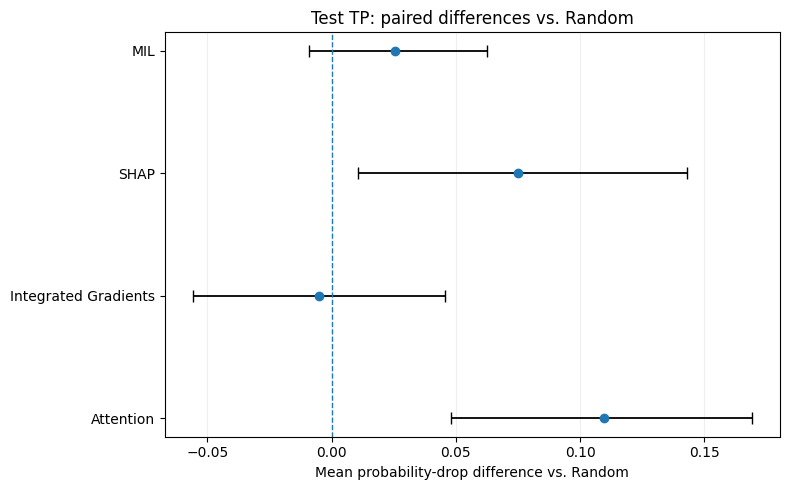

In [109]:
plot_baseline_mean_difference_ci(
    prob_drop_statistics,
    subset_name="Test TP",
    baseline="random",
    filename=(
        "prob_drop_difference_ci_"
        "test_tp_vs_random"
    ),
)

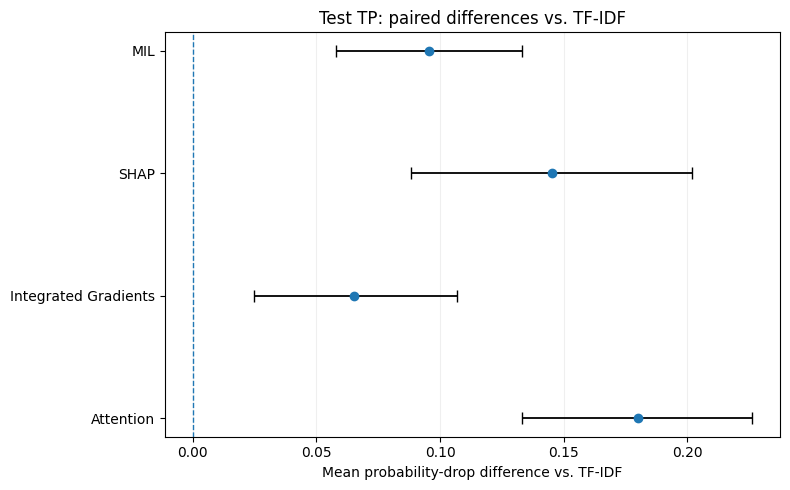

In [110]:
plot_baseline_mean_difference_ci(
    prob_drop_statistics,
    subset_name="Test TP",
    baseline="tfidf",
    filename=(
        "prob_drop_difference_ci_"
        "test_tp_vs_tfidf"
    ),
)

In [111]:
# ---------------------------------------------------------------------
# Prediction flip comparisons against baselines
# ---------------------------------------------------------------------

flip_stat_rows = []

comparison_index = 0


for subset_name, subset_df in STAT_SUBSETS.items():

    for baseline in STAT_BASELINES:

        for method in STAT_METHODS:

            paired = (
                subset_df.loc[
                    subset_df["method"].isin([
                        method,
                        baseline,
                    ]),
                    [
                        "global_row_id",
                        "method",
                        "prediction_flipped",
                    ],
                ]
                .dropna(
                    subset=["prediction_flipped"]
                )
                .pivot_table(
                    index="global_row_id",
                    columns="method",
                    values="prediction_flipped",
                    aggfunc="first",
                )
            )

            if (
                method not in paired.columns
                or baseline not in paired.columns
            ):
                continue

            paired = (
                paired[
                    [
                        baseline,
                        method,
                    ]
                ]
                .dropna()
            )

            if paired.empty:
                continue

            method_flip = (
                paired[method]
                .astype(bool)
                .to_numpy()
            )

            baseline_flip = (
                paired[baseline]
                .astype(bool)
                .to_numpy()
            )

            method_flip_rate = (
                method_flip.mean()
            )

            baseline_flip_rate = (
                baseline_flip.mean()
            )

            paired_binary_difference = (
                method_flip.astype(float)
                - baseline_flip.astype(float)
            )

            (
                flip_rate_difference,
                ci_lower,
                ci_upper,
            ) = paired_bootstrap_mean_ci(
                paired_binary_difference,
                seed=(
                    STAT_RANDOM_SEED
                    + 30_000
                    + comparison_index
                ),
            )

            mcnemar_result = exact_mcnemar(
                method_flip,
                baseline_flip,
            )

            flip_stat_rows.append({
                "subset": subset_name,
                "method": method,
                "baseline": baseline,

                "n_pairs": len(paired),

                "flip_rate_method": (
                    method_flip_rate
                ),

                "flip_rate_baseline": (
                    baseline_flip_rate
                ),

                "flip_rate_difference": (
                    flip_rate_difference
                ),

                "flip_rate_difference_pp": (
                    flip_rate_difference * 100
                ),

                "ci_95_lower": (
                    ci_lower
                ),

                "ci_95_upper": (
                    ci_upper
                ),

                "ci_95_lower_pp": (
                    ci_lower * 100
                ),

                "ci_95_upper_pp": (
                    ci_upper * 100
                ),

                **mcnemar_result,
            })

            comparison_index += 1


flip_statistics = pd.DataFrame(
    flip_stat_rows
)

In [112]:
flip_statistics[
    "mcnemar_p_holm"
] = np.nan


for subset_name in (
    flip_statistics[
        "subset"
    ].unique()
):
    subset_mask = (
        flip_statistics[
            "subset"
        ].eq(subset_name)
    )

    flip_statistics.loc[
        subset_mask,
        "mcnemar_p_holm",
    ] = holm_adjust(
        flip_statistics.loc[
            subset_mask,
            "mcnemar_p",
        ].to_numpy()
    )


flip_statistics[
    "significant_holm_005"
] = (
    flip_statistics[
        "mcnemar_p_holm"
    ] < STAT_ALPHA
)


flip_statistics.to_csv(
    TABLE_DIR
    / "statistical_prediction_flip_vs_baselines.csv",
    index=False,
)


display(
    flip_statistics.style.format({
        "flip_rate_method": "{:.1%}",
        "flip_rate_baseline": "{:.1%}",

        "flip_rate_difference": "{:+.2%}",
        "flip_rate_difference_pp": "{:+.1f}",

        "ci_95_lower": "{:+.2%}",
        "ci_95_upper": "{:+.2%}",
        "ci_95_lower_pp": "{:+.1f}",
        "ci_95_upper_pp": "{:+.1f}",

        "mcnemar_p": "{:.4g}",
        "mcnemar_p_holm": "{:.4g}",
    })
)

,subset,method,baseline,n_pairs,flip_rate_method,flip_rate_baseline,flip_rate_difference,flip_rate_difference_pp,ci_95_lower,ci_95_upper,ci_95_lower_pp,ci_95_upper_pp,method_only_positive,baseline_only_positive,n_discordant,mcnemar_p,mcnemar_p_holm,significant_holm_005
0,Test overall,attention,random,438,37.0%,31.7%,+5.25%,+5.3,-0.92%,+11.42%,-0.9,+11.4,109,86,195,0.1149,0.2369,False
1,Test overall,ig,random,438,24.4%,31.7%,-7.31%,-7.3,-12.56%,-2.05%,-12.6,-2.1,57,89,146,0.01006,0.06034,False
2,Test overall,shap,random,438,19.6%,31.7%,-12.10%,-12.1,-18.26%,-5.94%,-18.3,-5.9,74,127,201,0.0002267,0.001814,True
3,Test overall,mil,random,438,27.6%,31.7%,-4.11%,-4.1,-8.45%,+0.23%,-8.4,+0.2,38,56,94,0.07898,0.2369,False
4,Test overall,attention,tfidf,438,37.0%,29.7%,+7.31%,+7.3,+1.60%,+12.79%,+1.6,+12.8,98,66,164,0.01524,0.07618,False
5,Test overall,ig,tfidf,438,24.4%,29.7%,-5.25%,-5.3,-10.50%,-0.23%,-10.5,-0.2,54,77,131,0.05417,0.2167,False
6,Test overall,shap,tfidf,438,19.6%,29.7%,-10.05%,-10.0,-16.21%,-3.88%,-16.2,-3.9,75,119,194,0.001943,0.0136,True
7,Test overall,mil,tfidf,438,27.6%,29.7%,-2.05%,-2.1,-7.31%,+3.20%,-7.3,+3.2,65,74,139,0.4976,0.4976,False
8,Test TP,attention,random,186,29.6%,23.7%,+5.91%,+5.9,-4.30%,+16.13%,-4.3,+16.1,55,44,99,0.3149,0.9446,False
9,Test TP,ig,random,186,15.1%,23.7%,-8.60%,-8.6,-16.67%,-1.08%,-16.7,-1.1,20,36,56,0.04405,0.1762,False


In [113]:
flip_statistics_tp = (
    flip_statistics
    .loc[
        flip_statistics[
            "subset"
        ].eq("Test TP")
    ]
    .copy()
)


flip_statistics_tp[
    "method_label"
] = (
    flip_statistics_tp["method"]
    .map(method_label)
)

flip_statistics_tp[
    "baseline_label"
] = (
    flip_statistics_tp["baseline"]
    .map(method_label)
)


display(
    flip_statistics_tp[
        [
            "method_label",
            "baseline_label",
            "n_pairs",

            "flip_rate_method",
            "flip_rate_baseline",

            "flip_rate_difference_pp",
            "ci_95_lower_pp",
            "ci_95_upper_pp",

            "method_only_positive",
            "baseline_only_positive",

            "mcnemar_p_holm",
            "significant_holm_005",
        ]
    ]
    .style
    .format({
        "flip_rate_method": "{:.1%}",
        "flip_rate_baseline": "{:.1%}",

        "flip_rate_difference_pp": "{:+.1f}",
        "ci_95_lower_pp": "{:+.1f}",
        "ci_95_upper_pp": "{:+.1f}",

        "mcnemar_p_holm": "{:.4g}",
    })
)

,method_label,baseline_label,n_pairs,flip_rate_method,flip_rate_baseline,flip_rate_difference_pp,ci_95_lower_pp,ci_95_upper_pp,method_only_positive,baseline_only_positive,mcnemar_p_holm,significant_holm_005
8,Attention,Random,186,29.6%,23.7%,+5.9,-4.3,+16.1,55,44,0.9446,False
9,Integrated Gradients,Random,186,15.1%,23.7%,-8.6,-16.7,-1.1,20,36,0.1762,False
10,SHAP,Random,186,23.7%,23.7%,+0.0,-9.7,+9.7,40,40,1,False
11,MIL,Random,186,25.8%,23.7%,+2.2,-2.7,+7.0,13,9,1,False
12,Attention,TF-IDF,186,29.6%,5.9%,+23.7,+16.7,+31.2,52,8,3.644e-08,True
13,Integrated Gradients,TF-IDF,186,15.1%,5.9%,+9.1,+3.2,+15.1,25,8,0.02276,True
14,SHAP,TF-IDF,186,23.7%,5.9%,+17.7,+10.8,+24.7,42,9,2.033e-05,True
15,MIL,TF-IDF,186,25.8%,5.9%,+19.9,+13.4,+26.3,40,3,2.417e-08,True
